# LIBRARY

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import keras
import tensorflow as tf
from keras import models, layers, optimizers, callbacks, regularizers, initializers
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score
import gzip 
import pickle 

# DATAFRAMES

In [61]:
with gzip.open("../1.DATASET/CMI_timeseries_dataset.pkl.gz", "rb") as f:
	 CMI_timeseries_dataset = pickle.load(f)

In [62]:
# Check how many subjects/time series
print(f"Number of time series: {len(CMI_timeseries_dataset)}")

Number of time series: 4437


## FIRST ANALYSES

### COLUMNS

In [63]:
df = CMI_timeseries_dataset[0].copy()

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   X                    200 non-null    float32
 1   Y                    200 non-null    float32
 2   Z                    200 non-null    float32
 3   enmo                 200 non-null    float32
 4   anglez               200 non-null    float32
 5   non-wear_flag        200 non-null    float32
 6   light                200 non-null    float32
 7   battery_voltage      200 non-null    float32
 8   weekday              200 non-null    float64
 9   quarter              200 non-null    float64
 10  relative_date_PCIAT  200 non-null    float32
 11  id                   200 non-null    int64  
 12  sii_binary           200 non-null    int64  
dtypes: float32(9), float64(2), int64(2)
memory usage: 13.4 KB


### CLASS BALANCE

In [65]:
# 1. Check class balance across all subjects
sii_distribution = [df['sii_binary'].iloc[0] for df in CMI_timeseries_dataset]
print(f"Class distribution: {sum(sii_distribution)} problematic, {len(sii_distribution)-sum(sii_distribution)} non-problematic")

Class distribution: 1480 problematic, 2957 non-problematic


### NULL VALUES

In [66]:
# Check if ANY nulls exist in the entire dataset
total_nulls = 0
for i, df in enumerate(CMI_timeseries_dataset):
    if df.isnull().any().any():
        total_nulls += df.isnull().sum().sum()
        print(f"DataFrame {i} has null values")

if total_nulls == 0:
    print("✅ No null values found in any DataFrame!")
else:
    print(f"❌ Found {total_nulls} total null values")

✅ No null values found in any DataFrame!


### UNIQUE VALUES

In [67]:
# Focus on columns that should have limited unique values
categorical_like = ['weekday', 'quarter', 'sii_binary', 'id', 'non-wear_flag']
continuous_like = ['X', 'Y', 'Z', 'enmo', 'anglez', 'light', 'battery_voltage', 'relative_date_PCIAT']

print("="*80)
print("CATEGORICAL/DISCRETE COLUMNS ANALYSIS")
print("="*80)

for col in categorical_like:
    all_values = set()
    for df in CMI_timeseries_dataset:
        all_values.update(df[col].unique())
    
    print(f"\n🔷 {col}:")
    print(f"   Unique values: {sorted(all_values)}")
    print(f"   Expected range: ", end="")
    
    if col == 'weekday':
        print("0-6 (7 days)")
    elif col == 'quarter':
        print("0-3 (4 quarters) or 0-95?")
    elif col == 'sii_binary':
        print("0 or 1 only")
    elif col == 'non-wear_flag':
        print("0 or 1 (binary)")
    elif col == 'id':
        print(f"Total unique subjects: {len(all_values)}")

print("\n" + "="*80)
print("CONTINUOUS COLUMNS - VALUE RANGES")
print("="*80)

for col in continuous_like:
    min_val = float('inf')
    max_val = float('-inf')
    
    for df in CMI_timeseries_dataset:
        col_min = df[col].min()
        col_max = df[col].max()
        min_val = min(min_val, col_min)
        max_val = max(max_val, col_max)
    
    print(f"\n📈 {col}:")
    print(f"   Range: [{min_val:.4f}, {max_val:.4f}]")
    
    # Check for potential issues
    if col in ['non-wear_flag', 'sii_binary'] and (min_val < 0 or max_val > 1):
        print(f"   ⚠️ WARNING: Binary column has values outside [0,1]!")

CATEGORICAL/DISCRETE COLUMNS ANALYSIS

🔷 weekday:
   Unique values: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
   Expected range: 0-6 (7 days)

🔷 quarter:
   Unique values: [1.0, 2.0, 3.0, 4.0]
   Expected range: 0-3 (4 quarters) or 0-95?

🔷 sii_binary:
   Unique values: [0, 1]
   Expected range: 0 or 1 only

🔷 id:
   Unique values: [3, 25, 48, 51, 52, 63, 68, 82, 85, 90, 116, 118, 121, 129, 130, 132, 133, 134, 135, 140, 142, 150, 164, 167, 178, 179, 198, 200, 201, 206, 210, 214, 219, 220, 230, 231, 235, 239, 257, 270, 276, 277, 282, 284, 287, 300, 302, 310, 325, 339, 341, 347, 348, 354, 355, 367, 379, 380, 381, 382, 399, 407, 421, 428, 434, 459, 463, 465, 480, 503, 511, 514, 516, 520, 522, 523, 531, 537, 555, 558, 560, 566, 574, 575, 580, 599, 601, 606, 613, 633, 634, 642, 654, 657, 668, 670, 675, 681, 691, 692, 699, 706, 714, 717, 723, 732, 734, 735, 736, 739, 745, 749, 755, 764, 777, 783, 787, 789, 795, 797, 799, 828, 833, 835, 836, 839, 847, 851, 858, 861, 864, 881, 883, 884, 893, 894, 90

In [68]:
import gzip
import pickle
from collections import Counter

all_ids = []
for df in CMI_timeseries_dataset:
    # Get the unique ID from each DataFrame (assuming all rows have same ID)
    subject_id = df['id'].iloc[0]
    all_ids.append(subject_id)

# Count frequency of each ID
id_counts = Counter(all_ids)

print("="*80)
print("ID FREQUENCY ANALYSIS")
print("="*80)
print(f"\nTotal DataFrames: {len(all_ids)}")
print(f"Unique IDs: {len(id_counts)}")
print(f"IDs appearing more than once: {sum(1 for count in id_counts.values() if count > 1)}")
print(f"IDs appearing only once: {sum(1 for count in id_counts.values() if count == 1)}")

# Show IDs with multiple appearances
duplicate_ids = {id_: count for id_, count in id_counts.items() if count > 1}
if duplicate_ids:
    print(f"\n⚠️ IDs that appear in multiple DataFrames:")
    for id_, count in sorted(duplicate_ids.items(), key=lambda x: x[1], reverse=True):
        print(f"   ID {id_}: appears {count} times")
else:
    print("\n✅ Each ID appears exactly once across all DataFrames")



ID FREQUENCY ANALYSIS

Total DataFrames: 4437
Unique IDs: 494
IDs appearing more than once: 253
IDs appearing only once: 241

⚠️ IDs that appear in multiple DataFrames:
   ID 2043: appears 36 times
   ID 1935: appears 35 times
   ID 210: appears 34 times
   ID 2712: appears 34 times
   ID 736: appears 33 times
   ID 633: appears 33 times
   ID 1397: appears 33 times
   ID 1328: appears 33 times
   ID 580: appears 32 times
   ID 339: appears 32 times
   ID 1221: appears 32 times
   ID 835: appears 32 times
   ID 3632: appears 32 times
   ID 130: appears 31 times
   ID 634: appears 31 times
   ID 1422: appears 31 times
   ID 3187: appears 31 times
   ID 480: appears 31 times
   ID 2342: appears 31 times
   ID 675: appears 31 times
   ID 1777: appears 31 times
   ID 118: appears 30 times
   ID 407: appears 30 times
   ID 2258: appears 30 times
   ID 1267: appears 30 times
   ID 379: appears 30 times
   ID 3042: appears 29 times
   ID 1044: appears 29 times
   ID 2334: appears 29 times
   

#### NON WEAR FLAG

In [69]:
print("="*80)
print("CONSTANT VS VARYING NON-WEAR_FLAG ANALYSIS")
print("="*80)

# Categorize datasets
constant_wear = []  # Always 0
constant_non_wear = []  # Always 1
varying = []  # Changes over time

for i, df in enumerate(CMI_timeseries_dataset):
    unique_vals = df['non-wear_flag'].unique()
    
    if len(unique_vals) == 1:
        if unique_vals[0] == 0:
            constant_wear.append(i)
        else:
            constant_non_wear.append(i)
    else:
        varying.append(i)

print(f"\nCategorization of {len(CMI_timeseries_dataset)} datasets:")
print(f"  ✓ Always wearing (constant 0): {len(constant_wear)} ({len(constant_wear)/len(CMI_timeseries_dataset)*100:.1f}%)")
print(f"  ✗ Always non-wear (constant 1): {len(constant_non_wear)} ({len(constant_non_wear)/len(CMI_timeseries_dataset)*100:.1f}%)")
print(f"  ~ Varying wear pattern: {len(varying)} ({len(varying)/len(CMI_timeseries_dataset)*100:.1f}%)")

# Class distribution for constant vs varying
if constant_wear:
    const_wear_class = [CMI_timeseries_dataset[i]['sii_binary'].iloc[0] for i in constant_wear]
    print(f"\nClass distribution for constant wear subjects:")
    print(f"  Problematic: {sum(const_wear_class)} / Non-problematic: {len(const_wear_class)-sum(const_wear_class)}")

if varying:
    varying_class = [CMI_timeseries_dataset[i]['sii_binary'].iloc[0] for i in varying]
    print(f"\nClass distribution for varying wear subjects:")
    print(f"  Problematic: {sum(varying_class)} / Non-problematic: {len(varying_class)-sum(varying_class)}")


CONSTANT VS VARYING NON-WEAR_FLAG ANALYSIS

Categorization of 4437 datasets:
  ✓ Always wearing (constant 0): 4258 (96.0%)
  ✗ Always non-wear (constant 1): 17 (0.4%)
  ~ Varying wear pattern: 162 (3.7%)

Class distribution for constant wear subjects:
  Problematic: 1403 / Non-problematic: 2855

Class distribution for varying wear subjects:
  Problematic: 68 / Non-problematic: 94


CONSTANT VS VARYING NON-WEAR_FLAG ANALYSIS

Categorization of 4437 datasets:
  ✓ Always wearing (constant 0): 4258 (96.0%)
  ✗ Always non-wear (constant 1): 17 (0.4%)
  ~ Varying wear pattern: 162 (3.7%)

📊 Class distribution for ✓ Always wearing (constant 0):
  Problematic (sii_binary=1): 1403 (32.9%)
  Non-problematic (sii_binary=0): 2855 (67.1%)

📊 Class distribution for ✗ Always non-wear (constant 1):
  Problematic (sii_binary=1): 9 (52.9%)
  Non-problematic (sii_binary=0): 8 (47.1%)

📊 Class distribution for ~ Varying wear pattern:
  Problematic (sii_binary=1): 68 (42.0%)
  Non-problematic (sii_binary=0): 94 (58.0%)

CLASS DISTRIBUTION COMPARISON ACROSS GROUPS
          Group  Total Subjects  Problematic  Non-problematic  % Problematic
 Always Wearing            4258         1403             2855      32.949742
Always Non-wear              17            9                8      52.941176
Varying Pattern             162           68               94      41.975309

📊 Statistical Ana

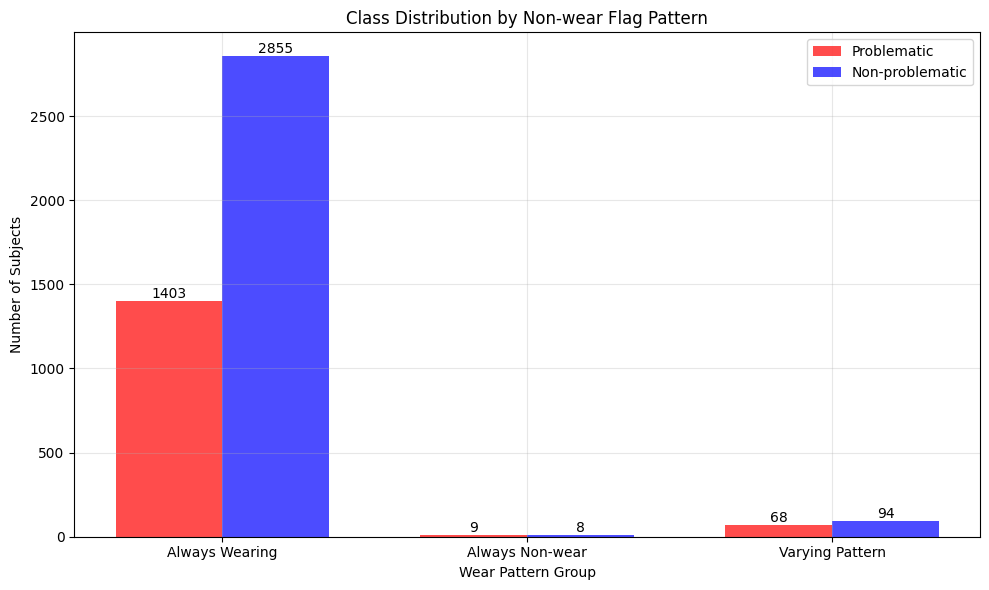

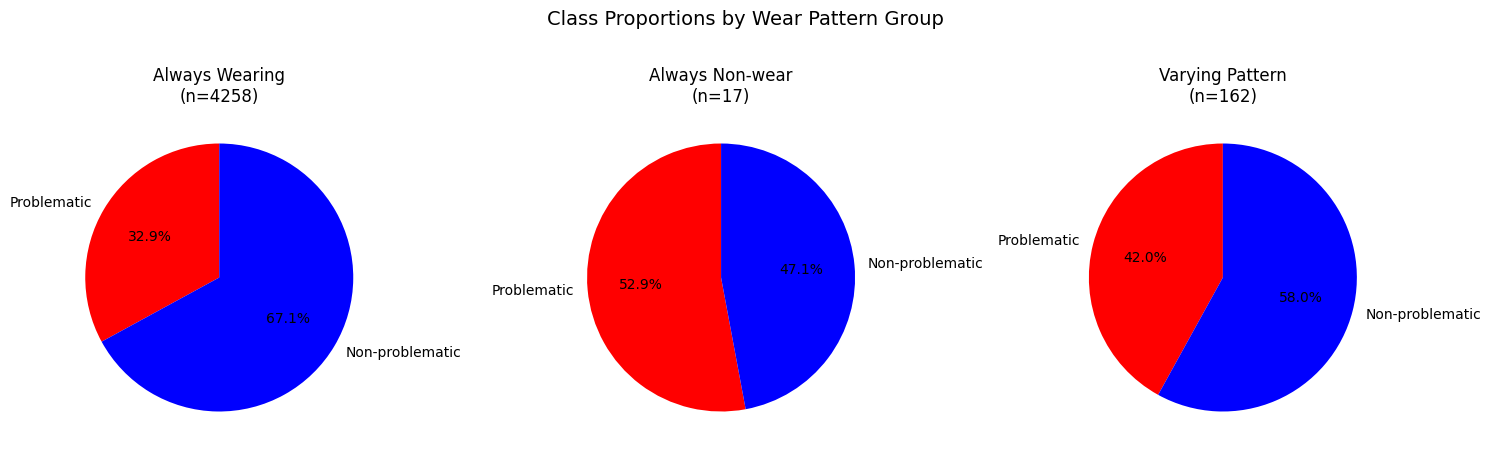

In [70]:
print("="*80)
print("CONSTANT VS VARYING NON-WEAR_FLAG ANALYSIS")
print("="*80)

# Categorize datasets
constant_wear = []  # Always 0
constant_non_wear = []  # Always 1
varying = []  # Changes over time

# Store class information for each category
constant_wear_classes = []
constant_non_wear_classes = []
varying_classes = []

for i, df in enumerate(CMI_timeseries_dataset):
    unique_vals = df['non-wear_flag'].unique()
    subject_class = df['sii_binary'].iloc[0]
    
    if len(unique_vals) == 1:
        if unique_vals[0] == 0:
            constant_wear.append(i)
            constant_wear_classes.append(subject_class)
        else:
            constant_non_wear.append(i)
            constant_non_wear_classes.append(subject_class)
    else:
        varying.append(i)
        varying_classes.append(subject_class)

print(f"\nCategorization of {len(CMI_timeseries_dataset)} datasets:")
print(f"  ✓ Always wearing (constant 0): {len(constant_wear)} ({len(constant_wear)/len(CMI_timeseries_dataset)*100:.1f}%)")
print(f"  ✗ Always non-wear (constant 1): {len(constant_non_wear)} ({len(constant_non_wear)/len(CMI_timeseries_dataset)*100:.1f}%)")
print(f"  ~ Varying wear pattern: {len(varying)} ({len(varying)/len(CMI_timeseries_dataset)*100:.1f}%)")

# Class distribution for constant wear (always wearing)
if constant_wear:
    prob_count = sum(constant_wear_classes)
    nonprob_count = len(constant_wear_classes) - prob_count
    print(f"\n📊 Class distribution for ✓ Always wearing (constant 0):")
    print(f"  Problematic (sii_binary=1): {prob_count} ({prob_count/len(constant_wear_classes)*100:.1f}%)")
    print(f"  Non-problematic (sii_binary=0): {nonprob_count} ({nonprob_count/len(constant_wear_classes)*100:.1f}%)")

# Class distribution for constant non-wear (always not wearing)
if constant_non_wear:
    prob_count = sum(constant_non_wear_classes)
    nonprob_count = len(constant_non_wear_classes) - prob_count
    print(f"\n📊 Class distribution for ✗ Always non-wear (constant 1):")
    print(f"  Problematic (sii_binary=1): {prob_count} ({prob_count/len(constant_non_wear_classes)*100:.1f}%)")
    print(f"  Non-problematic (sii_binary=0): {nonprob_count} ({nonprob_count/len(constant_non_wear_classes)*100:.1f}%)")

# Class distribution for varying wear pattern
if varying:
    prob_count = sum(varying_classes)
    nonprob_count = len(varying_classes) - prob_count
    print(f"\n📊 Class distribution for ~ Varying wear pattern:")
    print(f"  Problematic (sii_binary=1): {prob_count} ({prob_count/len(varying_classes)*100:.1f}%)")
    print(f"  Non-problematic (sii_binary=0): {nonprob_count} ({nonprob_count/len(varying_classes)*100:.1f}%)")

# Comparison of class distributions across groups
print("\n" + "="*80)
print("CLASS DISTRIBUTION COMPARISON ACROSS GROUPS")
print("="*80)

# Create a summary table
summary_data = {
    'Group': ['Always Wearing', 'Always Non-wear', 'Varying Pattern'],
    'Total Subjects': [len(constant_wear), len(constant_non_wear), len(varying)],
    'Problematic': [sum(constant_wear_classes), sum(constant_non_wear_classes), sum(varying_classes)],
    'Non-problematic': [len(constant_wear_classes)-sum(constant_wear_classes), 
                        len(constant_non_wear_classes)-sum(constant_non_wear_classes),
                        len(varying_classes)-sum(varying_classes)],
    '% Problematic': [sum(constant_wear_classes)/len(constant_wear_classes)*100 if constant_wear else 0,
                      sum(constant_non_wear_classes)/len(constant_non_wear_classes)*100 if constant_non_wear else 0,
                      sum(varying_classes)/len(varying_classes)*100 if varying else 0]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Statistical test for significant differences in class distribution
from scipy.stats import chi2_contingency
import numpy as np

# Create contingency table
contingency_table = np.array([
    [sum(constant_wear_classes), len(constant_wear_classes)-sum(constant_wear_classes)],
    [sum(constant_non_wear_classes), len(constant_non_wear_classes)-sum(constant_non_wear_classes)],
    [sum(varying_classes), len(varying_classes)-sum(varying_classes)]
])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\n📊 Statistical Analysis:")
print(f"  Chi-square test for class distribution across groups:")
print(f"    Chi-square statistic: {chi2:.4f}")
print(f"    p-value: {p:.4f}")
print(f"    {'✓ Significant difference between groups' if p < 0.05 else '✗ No significant difference between groups'}")

# Calculate odds ratios relative to always wearing group
if constant_wear and constant_non_wear:
    # Odds ratio: Always Non-wear vs Always Wearing
    odds_wearing = sum(constant_wear_classes) / (len(constant_wear_classes)-sum(constant_wear_classes)) if (len(constant_wear_classes)-sum(constant_wear_classes)) > 0 else float('inf')
    odds_nonwear = sum(constant_non_wear_classes) / (len(constant_non_wear_classes)-sum(constant_non_wear_classes)) if (len(constant_non_wear_classes)-sum(constant_non_wear_classes)) > 0 else float('inf')
    odds_ratio_nonwear_vs_wearing = odds_nonwear / odds_wearing if odds_wearing > 0 else float('inf')
    
    print(f"\n  Odds Ratios (relative to Always Wearing group):")
    print(f"    Always Non-wear group: {odds_ratio_nonwear_vs_wearing:.4f}")
    
if constant_wear and varying:
    odds_varying = sum(varying_classes) / (len(varying_classes)-sum(varying_classes)) if (len(varying_classes)-sum(varying_classes)) > 0 else float('inf')
    odds_ratio_varying_vs_wearing = odds_varying / odds_wearing if odds_wearing > 0 else float('inf')
    print(f"    Varying Pattern group: {odds_ratio_varying_vs_wearing:.4f}")

# Visualize class distribution
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for grouped bar chart
groups = ['Always Wearing', 'Always Non-wear', 'Varying Pattern']
problematic_counts = [sum(constant_wear_classes), sum(constant_non_wear_classes), sum(varying_classes)]
nonprob_counts = [len(constant_wear_classes)-sum(constant_wear_classes), 
                  len(constant_non_wear_classes)-sum(constant_non_wear_classes),
                  len(varying_classes)-sum(varying_classes)]

x = np.arange(len(groups))
width = 0.35

bars1 = ax.bar(x - width/2, problematic_counts, width, label='Problematic', color='red', alpha=0.7)
bars2 = ax.bar(x + width/2, nonprob_counts, width, label='Non-problematic', color='blue', alpha=0.7)

ax.set_xlabel('Wear Pattern Group')
ax.set_ylabel('Number of Subjects')
ax.set_title('Class Distribution by Non-wear Flag Pattern')
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Also create a pie chart for each group to show proportions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

groups_data = [
    ('Always Wearing', constant_wear_classes),
    ('Always Non-wear', constant_non_wear_classes),
    ('Varying Pattern', varying_classes)
]

for idx, (group_name, class_data) in enumerate(groups_data):
    if class_data:
        prob_count = sum(class_data)
        nonprob_count = len(class_data) - prob_count
        axes[idx].pie([prob_count, nonprob_count], labels=['Problematic', 'Non-problematic'], 
                     autopct='%1.1f%%', colors=['red', 'blue'], startangle=90)
        axes[idx].set_title(f'{group_name}\n(n={len(class_data)})')

plt.suptitle('Class Proportions by Wear Pattern Group', fontsize=14)
plt.tight_layout()
plt.show()

In [71]:
import gzip
import pickle
import pandas as pd

print("="*80)
print("EXTRACTING IDs BY NON-WEAR_FLAG PATTERN")
print("="*80)

# Categorize datasets
always_non_wear_ids = []  # Constant 1
varying_wear_ids = []     # Changes over time
always_wear_ids = []      # Constant 0 (for reference)

for i, df in enumerate(CMI_timeseries_dataset):
    unique_vals = df['non-wear_flag'].unique()
    subject_id = df['id'].iloc[0]
    sii_class = df['sii_binary'].iloc[0]
    
    if len(unique_vals) == 1:
        if unique_vals[0] == 1:
            always_non_wear_ids.append({
                'dataframe_idx': i,
                'id': subject_id,
                'sii_binary': sii_class,
                'class': 'Problematic' if sii_class == 1 else 'Non-problematic'
            })
        elif unique_vals[0] == 0:
            always_wear_ids.append({
                'dataframe_idx': i,
                'id': subject_id,
                'sii_binary': sii_class,
                'class': 'Problematic' if sii_class == 1 else 'Non-problematic'
            })
    else:
        varying_wear_ids.append({
            'dataframe_idx': i,
            'id': subject_id,
            'sii_binary': sii_class,
            'class': 'Problematic' if sii_class == 1 else 'Non-problematic',
            'n_unique_flags': len(unique_vals),
            'changes': (df['non-wear_flag'].diff() != 0).sum()
        })

# Print results
print(f"\n✅ Category 1: Always Non-wear (constant 1)")
print(f"   Count: {len(always_non_wear_ids)}")
if always_non_wear_ids:
    print("\n   IDs and details:")
    for item in always_non_wear_ids:
        print(f"     - ID: {item['id']} (DataFrame {item['dataframe_idx']}, Class: {item['class']})")
else:
    print("   No subjects in this category")

print(f"\n✅ Category 2: Varying Wear Pattern")
print(f"   Count: {len(varying_wear_ids)}")
if varying_wear_ids:
    print("\n   First 20 IDs (of {len(varying_wear_ids)}):")
    for item in varying_wear_ids[:20]:
        print(f"     - ID: {item['id']} (DataFrame {item['dataframe_idx']}, Class: {item['class']}, Changes: {item['changes']})")
    
    # Save full list to file
    if len(varying_wear_ids) > 20:
        varying_df = pd.DataFrame(varying_wear_ids)
        varying_df.to_csv('varying_wear_pattern_ids.csv', index=False)
        print(f"\n   📁 Full list of {len(varying_wear_ids)} IDs saved to 'varying_wear_pattern_ids.csv'")
else:
    print("   No subjects in this category")

print(f"\n📊 Reference: Always Wear (constant 0)")
print(f"   Count: {len(always_wear_ids)}")

EXTRACTING IDs BY NON-WEAR_FLAG PATTERN

✅ Category 1: Always Non-wear (constant 1)
   Count: 17

   IDs and details:
     - ID: 975 (DataFrame 43, Class: Non-problematic)
     - ID: 2405 (DataFrame 280, Class: Non-problematic)
     - ID: 2206 (DataFrame 796, Class: Problematic)
     - ID: 2158 (DataFrame 1187, Class: Non-problematic)
     - ID: 1920 (DataFrame 1266, Class: Non-problematic)
     - ID: 2922 (DataFrame 1587, Class: Non-problematic)
     - ID: 981 (DataFrame 1843, Class: Problematic)
     - ID: 3746 (DataFrame 2163, Class: Problematic)
     - ID: 2284 (DataFrame 2292, Class: Problematic)
     - ID: 3835 (DataFrame 2487, Class: Problematic)
     - ID: 894 (DataFrame 2567, Class: Problematic)
     - ID: 956 (DataFrame 2651, Class: Non-problematic)
     - ID: 142 (DataFrame 2889, Class: Non-problematic)
     - ID: 717 (DataFrame 2906, Class: Problematic)
     - ID: 1017 (DataFrame 2959, Class: Problematic)
     - ID: 3716 (DataFrame 3438, Class: Non-problematic)
     - ID: 3

### DUPLICATES

In [ ]:
import gzip
import pickle
import pandas as pd
import hashlib


# print("="*80)
# print("DUPLICATE DATAFRAME DETECTION")
# print("="*80)
# print(f"Total DataFrames to check: {len(CMI_timeseries_dataset)}")

# # Check for exact duplicates using equals() method
# duplicate_pairs = []
# duplicate_indices = set()

# for i in range(len(CMI_timeseries_dataset)):
#     for j in range(i+1, len(CMI_timeseries_dataset)):
#         if CMI_timeseries_dataset[i].equals(CMI_timeseries_dataset[j]):
#             duplicate_pairs.append((i, j))
#             duplicate_indices.add(i)
#             duplicate_indices.add(j)

# if duplicate_pairs:
#     print(f"\n⚠️ Found {len(duplicate_pairs)} pairs of duplicate DataFrames!")
#     print(f"DataFrame indices involved: {sorted(duplicate_indices)}")
#     print("\nDuplicate pairs:")
#     for pair in duplicate_pairs:
#         print(f"  - DataFrame {pair[0]} == DataFrame {pair[1]}")
#         print(f"    (Subject ID: {CMI_timeseries_dataset[pair[0]]['id'].iloc[0]} sii: {CMI_timeseries_dataset[pair[0]]['sii_binary'].iloc[0]})")
# else:
#     print("\n✅ No exact duplicate DataFrames found!")

DUPLICATE DATAFRAME DETECTION
Total DataFrames to check: 4437

✅ No exact duplicate DataFrames found!


### STATISTICS

In [36]:
import gzip
import pickle
import pandas as pd
import numpy as np


print("="*80)
print("GLOBAL DESCRIPTIVE STATISTICS ACROSS ALL DATAFRAMES")
print("="*80)

# Initialize lists to collect all values
global_data = {col: [] for col in CMI_timeseries_dataset[0].columns}

# Collect values from all DataFrames
for df in CMI_timeseries_dataset:
    for col in global_data.keys():
        global_data[col].extend(df[col].values)

# Create DataFrame with all values
global_df = pd.DataFrame(global_data)

# Generate descriptive statistics
global_stats = global_df.describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99])

print("\n📊 GLOBAL DESCRIPTIVE STATISTICS (All Subjects Combined):")
print("="*80)
print(global_stats)

# Save to CSV
global_stats.to_csv('global_descriptive_statistics.csv')
print("\n💾 Saved to 'global_descriptive_statistics.csv'")

GLOBAL DESCRIPTIVE STATISTICS ACROSS ALL DATAFRAMES

📊 GLOBAL DESCRIPTIVE STATISTICS (All Subjects Combined):
                   X              Y              Z           enmo  \
count  887400.000000  887400.000000  887400.000000  887400.000000   
mean       -0.092578       0.003362      -0.091223       0.056764   
std         0.538658       0.358403       0.423635       0.084195   
min        -8.022103      -2.084078      -1.042407       0.000000   
1%         -0.928149      -0.828171      -0.976485       0.000000   
5%         -0.809811      -0.601036      -0.785295       0.001043   
10%        -0.728483      -0.461969      -0.630218       0.004837   
25%        -0.571236      -0.230633      -0.364926       0.014106   
50%        -0.202865       0.002289      -0.114865       0.030716   
75%         0.435963       0.236372       0.152181       0.066491   
90%         0.658907       0.469673       0.490473       0.128631   
95%         0.759112       0.608892       0.695505       0.192

In [37]:
global_df.shape

(887400, 13)

In [38]:
global_df[global_df['non-wear_flag']==0]

,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,weekday,quarter,relative_date_PCIAT,id,sii_binary
0,-0.696639,-0.058477,-0.086717,0.051424,-6.090168,0.0,21.794674,4023.000000,4.0,4.0,253.0,2265,0
1,-0.479150,0.218840,-0.289497,0.062909,-19.893288,0.0,20.835835,4023.000000,4.0,4.0,253.0,2265,0
2,-0.440287,-0.171177,-0.326227,0.121546,-23.043303,0.0,6.294650,4023.000000,4.0,4.0,253.0,2265,0
3,-0.559035,-0.293204,-0.145227,0.084953,-9.694811,0.0,0.462963,4022.616699,4.0,4.0,253.0,2265,0
4,-0.531364,-0.210126,-0.086370,0.074157,-6.412807,0.0,4.058062,4020.583252,4.0,4.0,253.0,2265,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
887395,0.109243,0.581290,0.320458,0.056306,20.626949,0.0,13.580427,3689.000000,5.0,2.0,36.0,580,1
887396,-0.524706,0.227063,0.363919,0.081404,23.889679,0.0,13.534304,3689.000000,5.0,2.0,36.0,580,1
887397,-0.451121,-0.028637,0.405358,0.034749,25.322130,0.0,13.487847,3689.000000,5.0,2.0,36.0,580,1
887398,0.548647,0.177419,-0.791097,0.020374,-53.796261,0.0,13.441450,3689.000000,5.0,2.0,36.0,580,1


### INDIVIDUAL GRAPHICS

In [78]:
df = CMI_timeseries_dataset[179].copy()
df

,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,weekday,quarter,relative_date_PCIAT,id,sii_binary
0,-0.490758,-0.216741,-0.830626,2.171927e-07,-57.165550,1.0,2.665892,4151.616699,3.0,1.0,16.0,1209,0
1,-0.490871,-0.216690,-0.830107,0.000000e+00,-57.162380,1.0,2.647305,4148.416504,3.0,1.0,16.0,1209,0
2,-0.490722,-0.216557,-0.830090,6.804201e-08,-57.170643,1.0,2.628718,4148.491699,3.0,1.0,16.0,1209,0
3,-0.490711,-0.216485,-0.830147,2.900097e-08,-57.172436,1.0,2.610130,4147.799805,3.0,1.0,16.0,1209,0
4,-0.490885,-0.216450,-0.829894,1.713501e-07,-57.161430,1.0,2.591543,4148.616699,3.0,1.0,16.0,1209,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.018569,0.863367,0.493587,1.348139e-01,29.647186,0.0,5.227971,4123.000000,3.0,1.0,16.0,1209,0
196,-0.027185,0.790512,0.484668,1.359492e-01,29.123150,0.0,4.307178,4123.000000,3.0,1.0,16.0,1209,0
197,-0.534845,-0.116629,0.408597,3.794097e-02,25.458132,0.0,3.386386,4123.000000,3.0,1.0,16.0,1209,0
198,-0.617096,0.359235,0.190643,3.785862e-02,11.685822,0.0,2.465594,4123.000000,3.0,1.0,16.0,1209,0


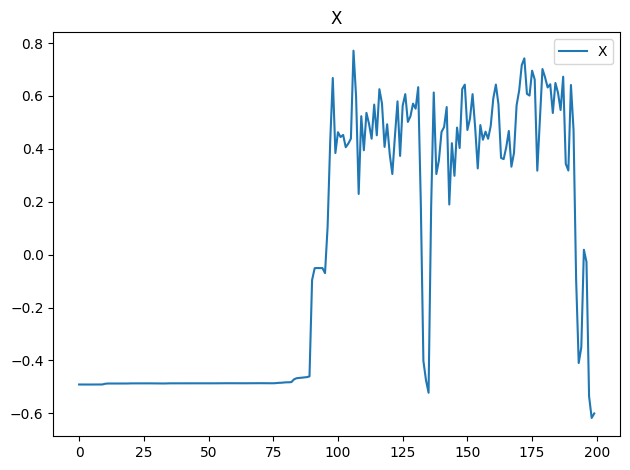

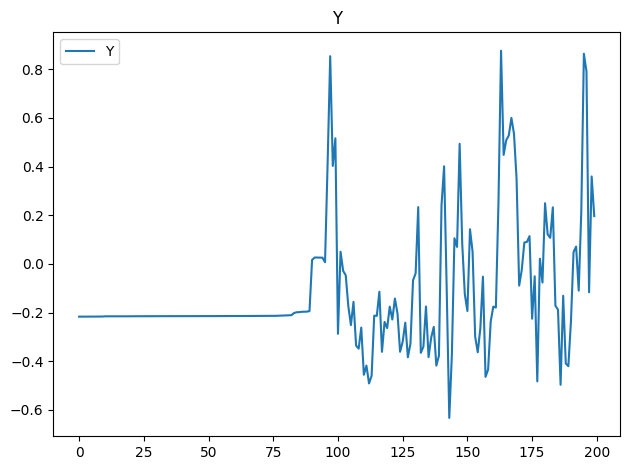

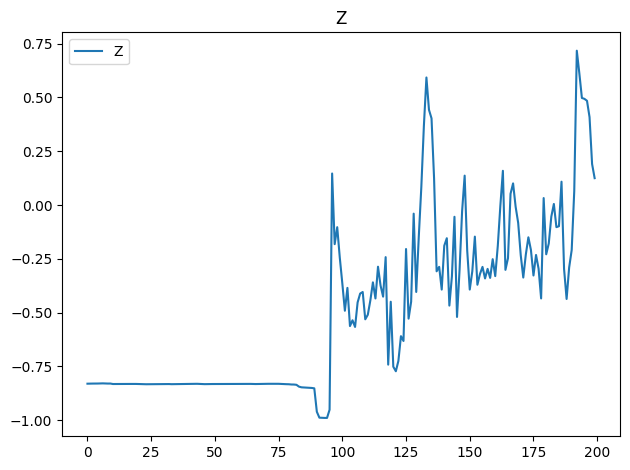

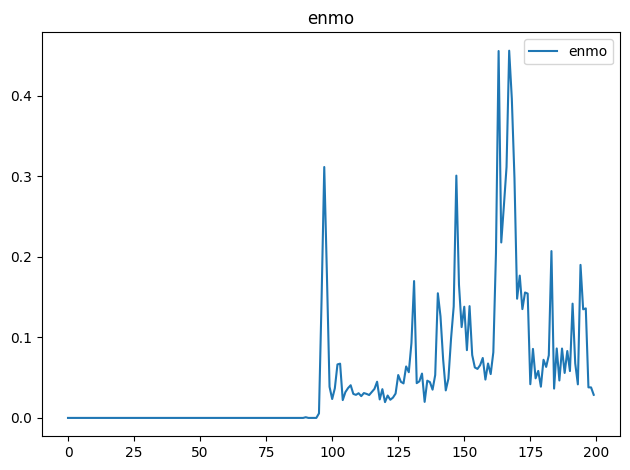

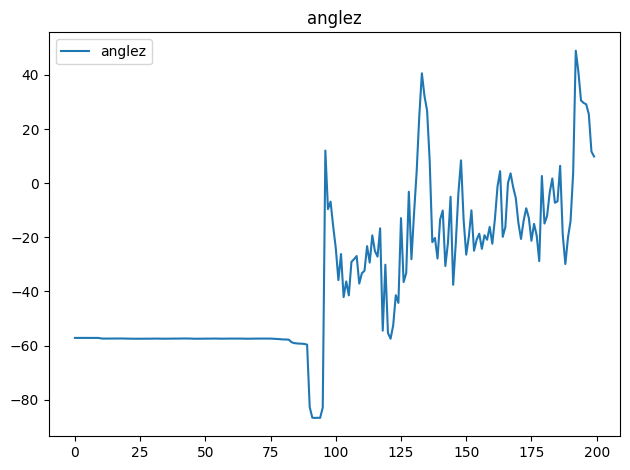

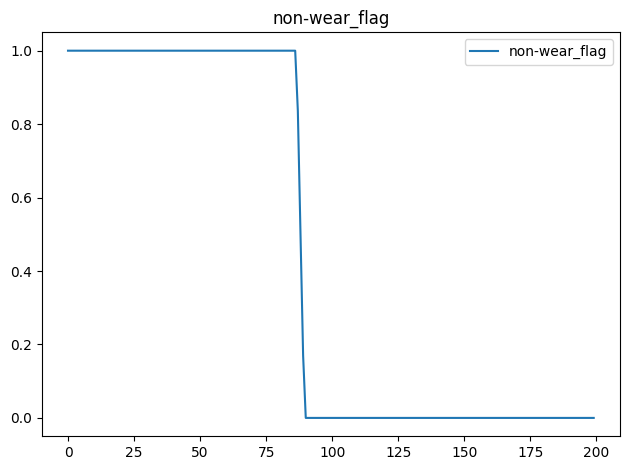

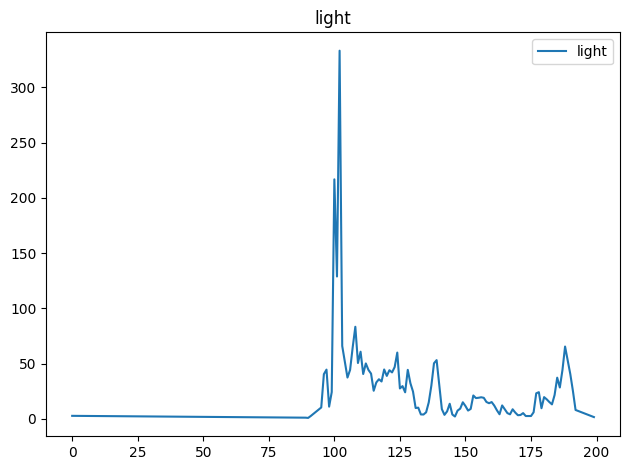

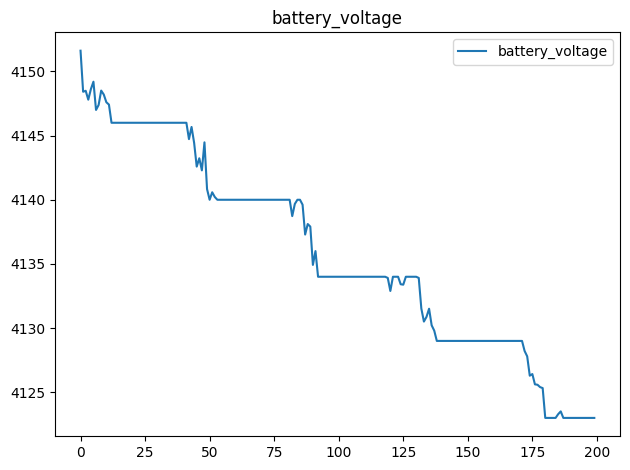

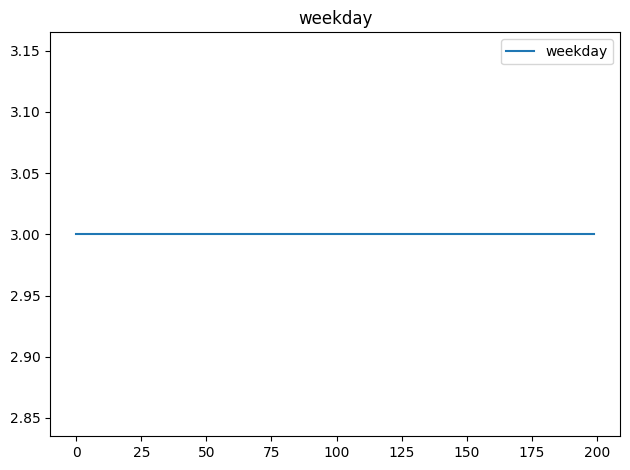

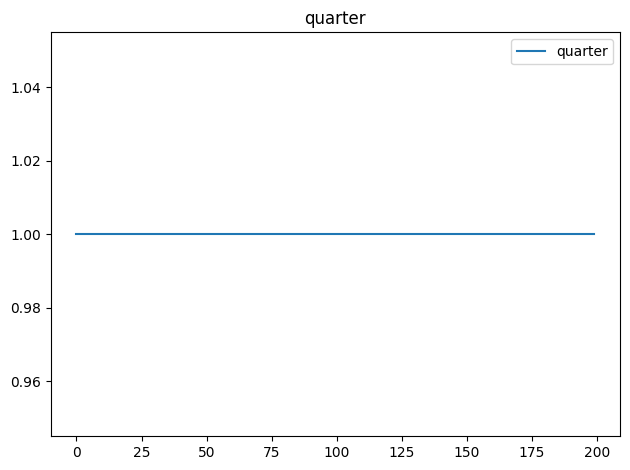

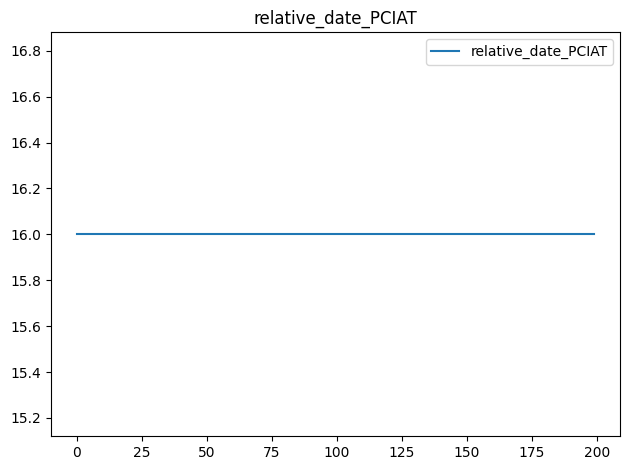

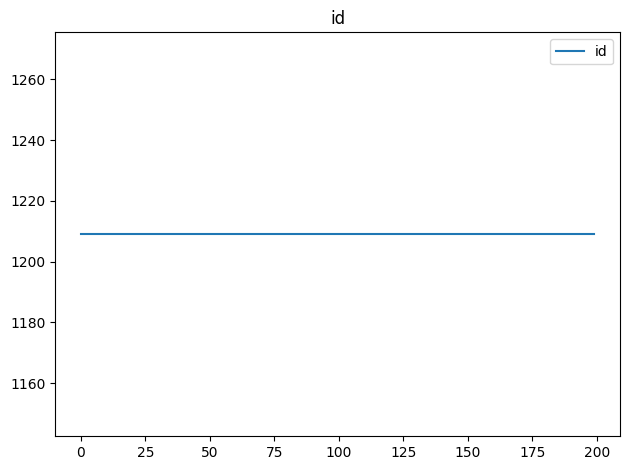

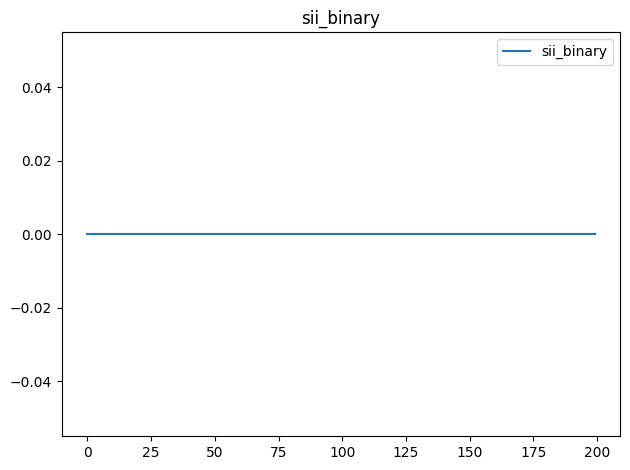

In [79]:
for col in df.columns:
    df[[col]].plot(title=col)
    plt.tight_layout()
    plt.show()

# SELECTION


In [73]:
print("="*60)
print("FILTERING VARYING WEAR SUBJECTS")
print("="*60)

# Analyze varying subjects
keep_indices = []
remove_indices = []

for i, df in enumerate(CMI_timeseries_dataset):
    vals = df['non-wear_flag'].values
    unique = np.unique(vals)
    
    # Always wearing (keep)
    if len(unique) == 1 and unique[0] == 0:
        keep_indices.append(i)
    
    # Varying pattern
    elif len(unique) > 1:
        wear_pct = np.mean(vals == 0) * 100
        if wear_pct >= 50:  # Keep if mostly wearing
            keep_indices.append(i)
        else:  # Remove if mostly non-wear
            remove_indices.append(i)

# Create filtered dataset
filtered_data = [CMI_timeseries_dataset[i] for i in keep_indices]

print(f"Original: {len(CMI_timeseries_dataset)}")
print(f"Kept: {len(filtered_data)} (always wear + mostly wear)")
print(f"Removed: {len(remove_indices)} (mostly non-wear)")

# Class distribution
original_prob = sum([df['sii_binary'].iloc[0] for df in CMI_timeseries_dataset])
filtered_prob = sum([df['sii_binary'].iloc[0] for df in filtered_data])

print(f"\nProblematic: {original_prob} → {filtered_prob}")
print(f"Non-problematic: {len(CMI_timeseries_dataset)-original_prob} → {len(filtered_data)-filtered_prob}")


FILTERING VARYING WEAR SUBJECTS
Original: 4437
Kept: 4304 (always wear + mostly wear)
Removed: 116 (mostly non-wear)

Problematic: 1480 → 1419
Non-problematic: 2957 → 2885


In [75]:
print("="*80)
print("ANALYZING VARYING WEAR PATTERN SUBJECTS")
print("="*80)

# First, identify varying wear subjects
varying_indices = []
varying_subjects_data = []

for i, df in enumerate(CMI_timeseries_dataset):
    unique_vals = df['non-wear_flag'].unique()
    if len(unique_vals) > 1:  # Varying pattern
        varying_indices.append(i)
        varying_subjects_data.append({
            'dataframe_idx': i,
            'id': df['id'].iloc[0],
            'sii_binary': df['sii_binary'].iloc[0],
            'non_wear_values': df['non-wear_flag'].values.copy()
        })

print(f"\nFound {len(varying_subjects_data)} varying wear subjects")

# Analyze each varying subject
varying_analysis = []

for subject in varying_subjects_data:
    non_wear_vals = subject['non_wear_values']
    
    # Calculate statistics
    total_steps = len(non_wear_vals)
    n_zeros = np.sum(non_wear_vals == 0)
    n_ones = np.sum(non_wear_vals == 1)
    percent_wearing = (n_zeros / total_steps) * 100
    percent_non_wear = (n_ones / total_steps) * 100
    
    # Count transitions
    transitions = np.sum(np.diff(non_wear_vals) != 0)
    
    # Determine dominant state
    if percent_wearing > 50:
        dominant_state = 0  # Mostly wearing
        dominant_label = "Mostly Wearing"
    else:
        dominant_state = 1  # Mostly non-wear
        dominant_label = "Mostly Non-wear"
    
    varying_analysis.append({
        'dataframe_idx': subject['dataframe_idx'],
        'id': subject['id'],
        'sii_binary': subject['sii_binary'],
        'class': 'Problematic' if subject['sii_binary'] == 1 else 'Non-problematic',
        'total_steps': total_steps,
        'wearing_steps': n_zeros,
        'non_wear_steps': n_ones,
        'percent_wearing': percent_wearing,
        'percent_non_wear': percent_non_wear,
        'transitions': transitions,
        'dominant_state': dominant_state,
        'dominant_label': dominant_label
    })

# Create DataFrame for analysis
varying_df = pd.DataFrame(varying_analysis)

# PRINT THE DATAFRAME
print("\n" + "="*80)
print("VARYING WEAR SUBJECTS - DETAILED DATAFRAME")
print("="*80)
print(varying_df.to_string(index=False))

print("\n" + "="*80)
print("VARYING WEAR PATTERN SUMMARY")
print("="*80)
print(f"\nTotal varying subjects: {len(varying_df)}")
print(f"\nDominant state distribution:")
print(f"  Mostly Wearing (0 dominant): {(varying_df['dominant_state'] == 0).sum()} subjects ({(varying_df['dominant_state'] == 0).sum()/len(varying_df)*100:.1f}%)")
print(f"  Mostly Non-wear (1 dominant): {(varying_df['dominant_state'] == 1).sum()} subjects ({(varying_df['dominant_state'] == 1).sum()/len(varying_df)*100:.1f}%)")

print(f"\nStatistics:")
print(f"  Average % wearing time: {varying_df['percent_wearing'].mean():.1f}%")
print(f"  Median % wearing time: {varying_df['percent_wearing'].median():.1f}%")
print(f"  Average transitions: {varying_df['transitions'].mean():.1f}")
print(f"  Min transitions: {varying_df['transitions'].min()}")
print(f"  Max transitions: {varying_df['transitions'].max()}")

# Show the mostly non-wear subjects
mostly_non_wear = varying_df[varying_df['dominant_state'] == 1]
print(f"\n🔴 Subjects that are MOSTLY NON-WEAR (>50% non-wear time):")
print(f"   Count: {len(mostly_non_wear)}")
if len(mostly_non_wear) > 0:
    print("\n   Details DataFrame:")
    print(mostly_non_wear[['id', 'class', 'percent_non_wear', 'transitions']].to_string(index=False))

# Show the mostly wearing subjects
mostly_wearing = varying_df[varying_df['dominant_state'] == 0]
print(f"\n🟢 Subjects that are MOSTLY WEARING (>50% wear time):")
print(f"   Count: {len(mostly_wearing)}")
print(f"   Average wear time: {mostly_wearing['percent_wearing'].mean():.1f}%")
print(f"\n   Details DataFrame (first 20):")
print(mostly_wearing[['id', 'class', 'percent_wearing', 'transitions']].head(20).to_string(index=False))

ANALYZING VARYING WEAR PATTERN SUBJECTS

Found 162 varying wear subjects

VARYING WEAR SUBJECTS - DETAILED DATAFRAME
 dataframe_idx   id  sii_binary           class  total_steps  wearing_steps  non_wear_steps  percent_wearing  percent_non_wear  transitions  dominant_state  dominant_label
             1   51           1     Problematic          200              3             185              1.5              92.5           15               1 Mostly Non-wear
            42 1088           1     Problematic          200            114              71             57.0              35.5           20               0  Mostly Wearing
            68  537           0 Non-problematic          200            107              75             53.5              37.5           24               0  Mostly Wearing
            77 3847           1     Problematic          200             30             158             15.0              79.0           15               1 Mostly Non-wear
            79 3460    

In [81]:
import gzip
import pickle
import pandas as pd
import numpy as np

print("="*80)
print("FILTERING DATASET - KEEPING ALWAYS-WEARING + MOSTLY WEARING SUBJECTS")
print("="*80)

# First, identify varying wear subjects and classify them
indices_to_keep = []
indices_to_drop = []

always_wear_indices = []      # Constant 0
always_non_wear_indices = []  # Constant 1
mostly_wear_indices = []      # Varying but mostly wearing (>=50%)
mostly_non_wear_indices = []  # Varying but mostly non-wear (<50%)

for i, df in enumerate(CMI_timeseries_dataset):
    unique_vals = df['non-wear_flag'].unique()
    
    if len(unique_vals) == 1:
        # Constant values
        if unique_vals[0] == 1 or (isinstance(unique_vals[0], float) and round(unique_vals[0]) == 1):
            always_non_wear_indices.append(i)
            indices_to_drop.append(i)
        elif unique_vals[0] == 0 or (isinstance(unique_vals[0], float) and round(unique_vals[0]) == 0):
            always_wear_indices.append(i)
            indices_to_keep.append(i)
    else:
        # Varying pattern - calculate wear percentage
        vals = df['non-wear_flag'].values
        wear_pct = np.mean(vals == 0) * 100
        
        if wear_pct >= 50:
            # Mostly wearing - KEEP
            mostly_wear_indices.append(i)
            indices_to_keep.append(i)
        else:
            # Mostly non-wear - DROP
            mostly_non_wear_indices.append(i)
            indices_to_drop.append(i)

print(f"\n📊 Dataset Composition:")
print(f"  Total DataFrames: {len(CMI_timeseries_dataset)}")
print(f"\n  ✓ KEEP:")
print(f"    - Always wearing (constant 0): {len(always_wear_indices)} ({len(always_wear_indices)/len(CMI_timeseries_dataset)*100:.1f}%)")
print(f"    - Mostly wearing (varying, ≥50% wear): {len(mostly_wear_indices)} ({len(mostly_wear_indices)/len(CMI_timeseries_dataset)*100:.1f}%)")
print(f"    Total KEPT: {len(indices_to_keep)} ({len(indices_to_keep)/len(CMI_timeseries_dataset)*100:.1f}%)")
print(f"\n  ✗ DROP:")
print(f"    - Always non-wear (constant 1): {len(always_non_wear_indices)} ({len(always_non_wear_indices)/len(CMI_timeseries_dataset)*100:.1f}%)")
print(f"    - Mostly non-wear (varying, <50% wear): {len(mostly_non_wear_indices)} ({len(mostly_non_wear_indices)/len(CMI_timeseries_dataset)*100:.1f}%)")
print(f"    Total DROPPED: {len(indices_to_drop)} ({len(indices_to_drop)/len(CMI_timeseries_dataset)*100:.1f}%)")

# Create filtered dataset
CMI_timeseries_filtered = [CMI_timeseries_dataset[i] for i in indices_to_keep]

print(f"\n✅ Created filtered dataset with {len(CMI_timeseries_filtered)} time series")
print(f"   - All subjects wear device at least 50% of the time")

# Verify filtered dataset
print(f"\n🔍 Verification (first 5 subjects):")
for i in range(min(5, len(CMI_timeseries_filtered))):
    df = CMI_timeseries_filtered[i]
    unique_vals = df['non-wear_flag'].unique()
    wear_pct = np.mean(df['non-wear_flag'].values == 0) * 100
    print(f"  Subject {df['id'].iloc[0]}: unique={unique_vals}, wear={wear_pct:.0f}%")

# Class distribution in filtered dataset
original_classes = [df['sii_binary'].iloc[0] for df in CMI_timeseries_dataset]
filtered_classes = [df['sii_binary'].iloc[0] for df in CMI_timeseries_filtered]

print(f"\n📊 Class Distribution Comparison:")
print(f"  Original - Problematic: {sum(original_classes)} ({sum(original_classes)/len(original_classes)*100:.1f}%)")
print(f"  Filtered - Problematic: {sum(filtered_classes)} ({sum(filtered_classes)/len(filtered_classes)*100:.1f}%)")

# Save filtered dataset
with gzip.open("CMI_timeseries_filtered.pkl.gz", "wb") as f:
    pickle.dump(CMI_timeseries_filtered, f)

print(f"\n💾 Filtered dataset saved to: CMI_timeseries_filtered.pkl.gz")

FILTERING DATASET - KEEPING ALWAYS-WEARING + MOSTLY WEARING SUBJECTS

📊 Dataset Composition:
  Total DataFrames: 4437

  ✓ KEEP:
    - Always wearing (constant 0): 4258 (96.0%)
    - Mostly wearing (varying, ≥50% wear): 46 (1.0%)
    Total KEPT: 4304 (97.0%)

  ✗ DROP:
    - Always non-wear (constant 1): 17 (0.4%)
    - Mostly non-wear (varying, <50% wear): 116 (2.6%)
    Total DROPPED: 133 (3.0%)

✅ Created filtered dataset with 4304 time series
   - All subjects wear device at least 50% of the time

🔍 Verification (first 5 subjects):
  Subject 2265: unique=[0.], wear=100%
  Subject 3042: unique=[0.], wear=100%
  Subject 1647: unique=[0.], wear=100%
  Subject 736: unique=[0.], wear=100%
  Subject 1044: unique=[0.], wear=100%

📊 Class Distribution Comparison:
  Original - Problematic: 1480 (33.4%)
  Filtered - Problematic: 1419 (33.0%)

💾 Filtered dataset saved to: CMI_timeseries_filtered.pkl.gz


## NULL VALUES 

In [82]:
import gzip
import pickle
import numpy as np

print("="*60)
print("CONVERTING NON-WEAR PERIODS TO NaN")
print("="*60)

# Load filtered dataset
with gzip.open("CMI_timeseries_filtered.pkl.gz", "rb") as f:
    data = pickle.load(f)

# Columns to convert to NaN (sensor data)
sensor_cols = ['X', 'Y', 'Z', 'enmo', 'anglez', 'light', 'battery_voltage']

# Convert non-wear periods to NaN
data_nan = []

for df in data:
    df_copy = df.copy()
    mask = df_copy['non-wear_flag'] == 1
    df_copy.loc[mask, sensor_cols] = np.nan
    data_nan.append(df_copy)

print(f"✅ Converted {len(data_nan)} time series")
print(f"   Non-wear periods → NaN")

# # Save
# with gzip.open("CMI_timeseries_nan.pkl.gz", "wb") as f:
#     pickle.dump(data_nan, f)

# print(f"💾 Saved: CMI_timeseries_nan.pkl.gz")

CONVERTING NON-WEAR PERIODS TO NaN
✅ Converted 4304 time series
   Non-wear periods → NaN


## INTERPOLATION

In [83]:
# Optional: Fill NaN values with interpolation
data_interp = []

for df in data_nan:
    df_copy = df.copy()
    for col in sensor_cols:
        df_copy[col] = df_copy[col].interpolate()
    data_interp.append(df_copy)



### INDIVIDUAL GRAPHICS

In [94]:
def get_id(data, target):
    return next((df for df in data if df['id'].iloc[0] == target), None)

# Use it
df_F = get_id(data, 1088)#1209           
print(df_F)

            X         Y         Z      enmo     anglez  non-wear_flag  light  \
0    0.095634 -0.332481  0.947009  0.008238  69.950386            0.0   10.0   
1    0.095556 -0.332615  0.946999  0.008275  69.937263            0.0   10.0   
2    0.095439 -0.333056  0.946900  0.008307  69.891380            0.0   10.0   
3    0.095472 -0.333064  0.946844  0.008260  69.880753            0.0   10.0   
4    0.095541 -0.333116  0.946835  0.008276  69.882484            0.0   10.0   
..        ...       ...       ...       ...        ...            ...    ...   
195  0.050110 -0.368218  0.938155  0.009090  68.343361            1.0   10.0   
196  0.050168 -0.368238  0.938264  0.009198  68.346107            1.0   10.0   
197  0.050094 -0.368216  0.938431  0.009342  68.357422            1.0   10.0   
198  0.050198 -0.368245  0.938381  0.009312  68.350342            1.0   10.0   
199  0.050110 -0.368272  0.938386  0.009321  68.352135            1.0   10.0   

     battery_voltage  weekday  quarter 

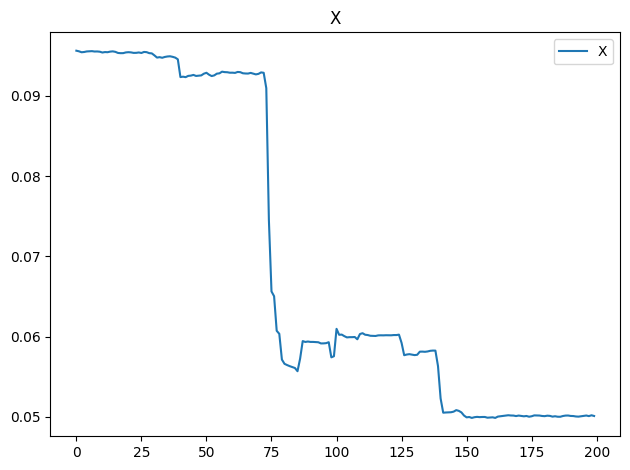

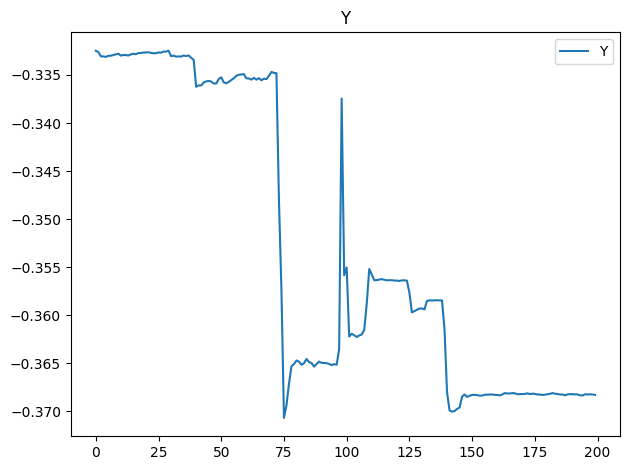

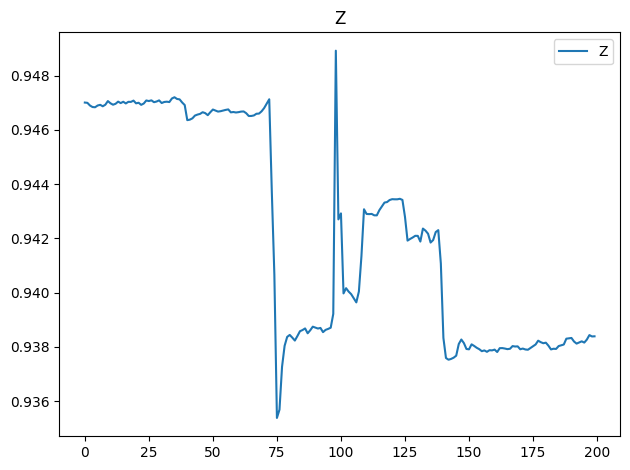

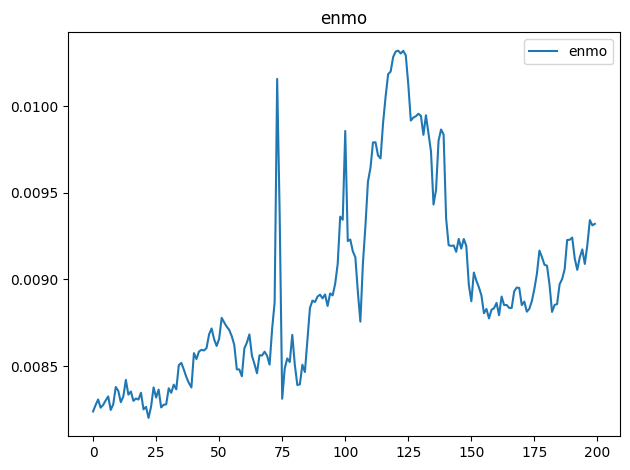

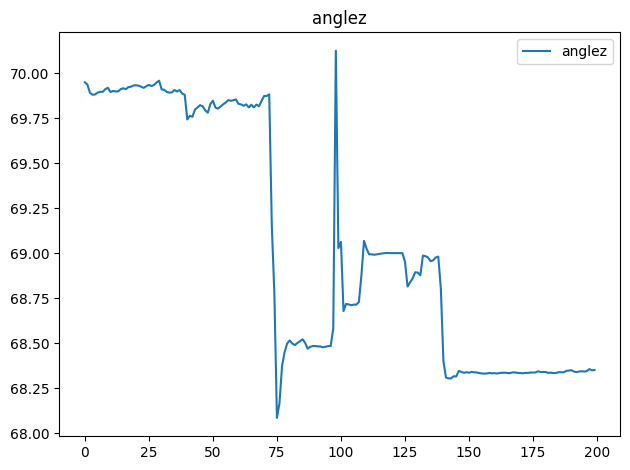

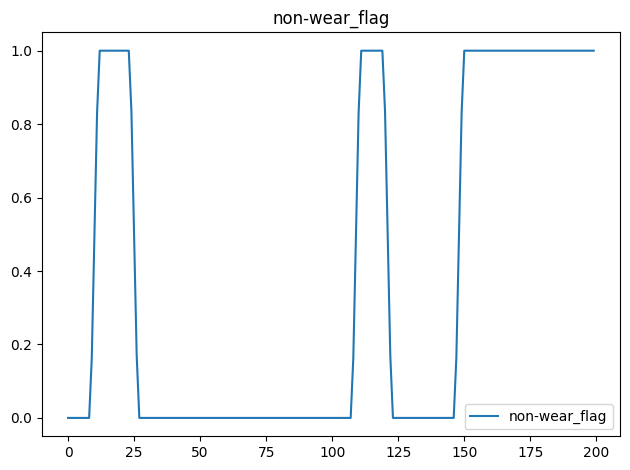

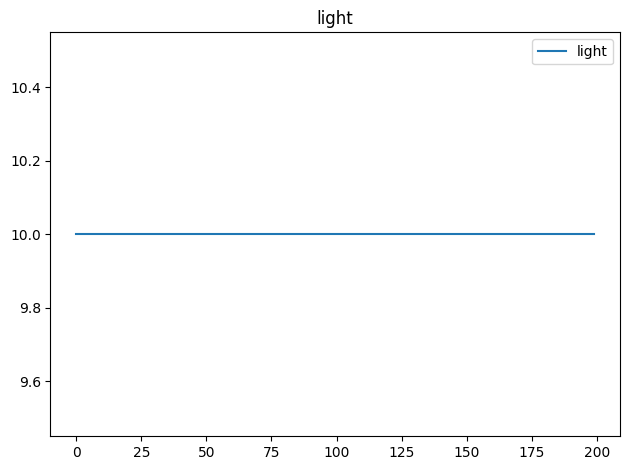

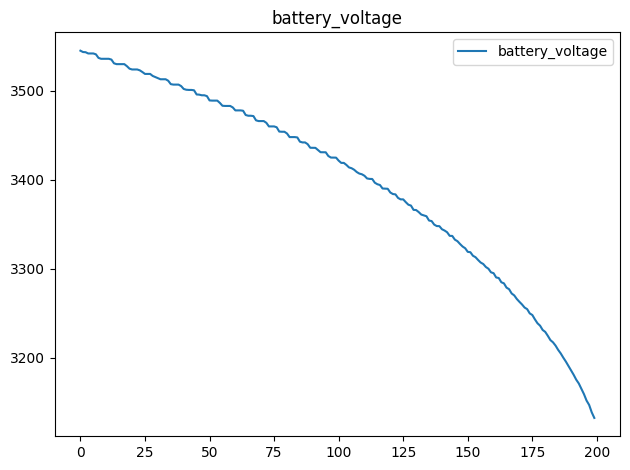

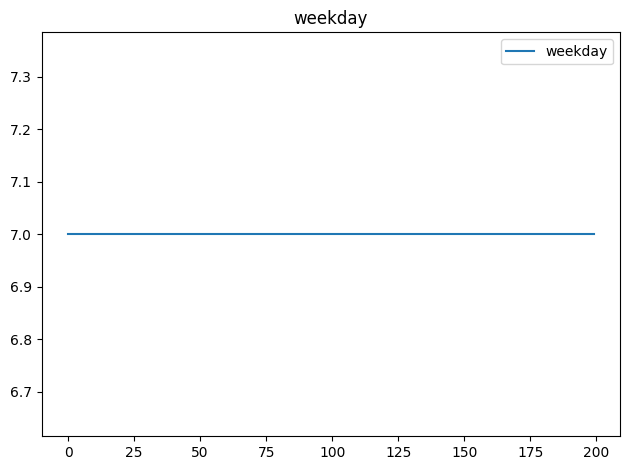

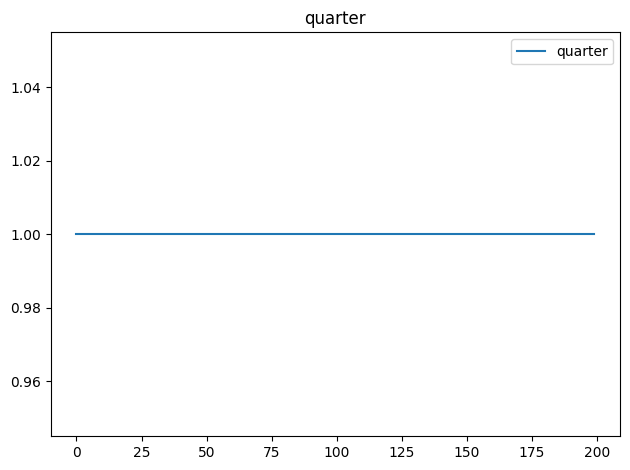

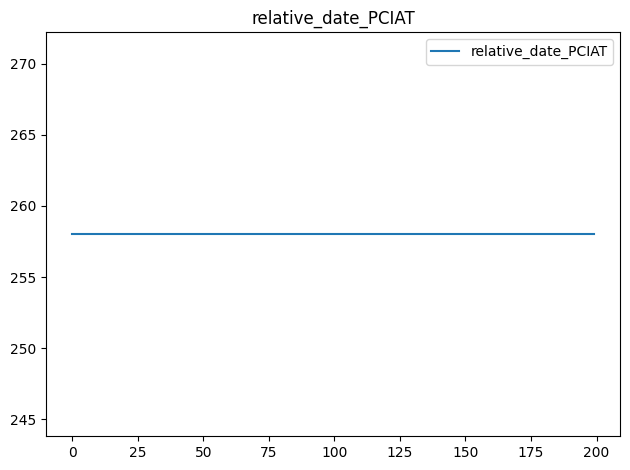

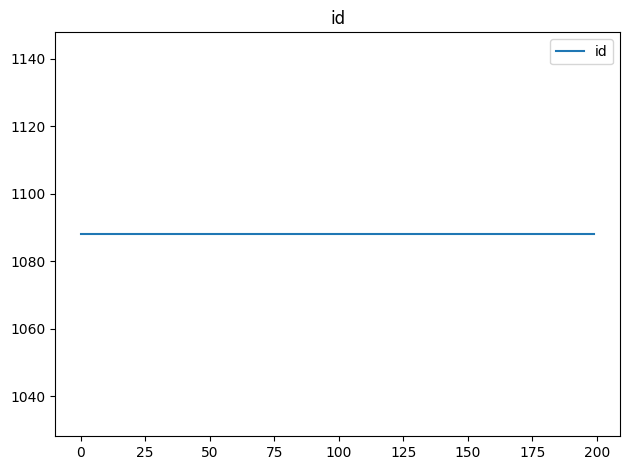

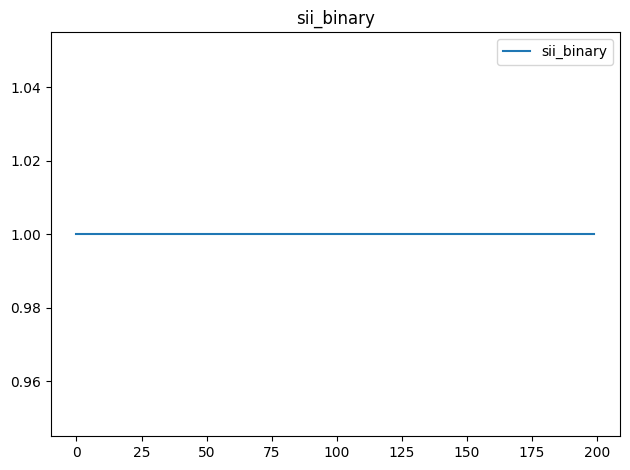

In [95]:
for col in df_F.columns:
    df_F[[col]].plot(title=col)
    plt.tight_layout()
    plt.show()

# NORMALIZATION

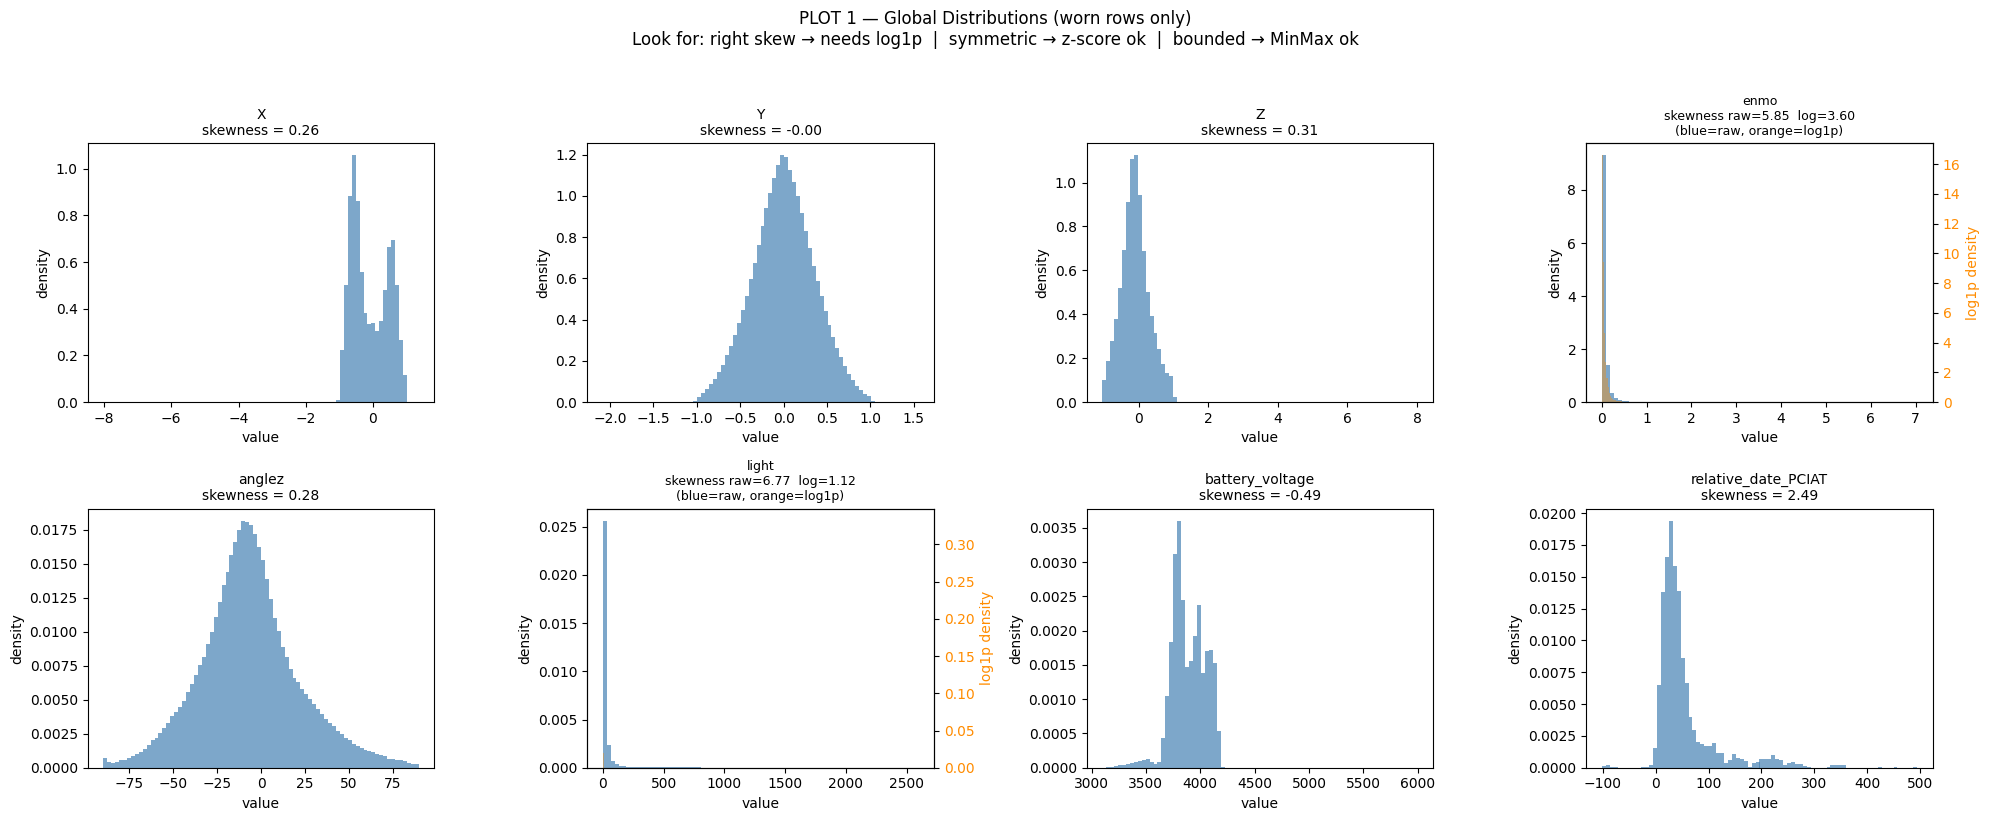

✅ Plot 1 saved: diag_1_distributions.png


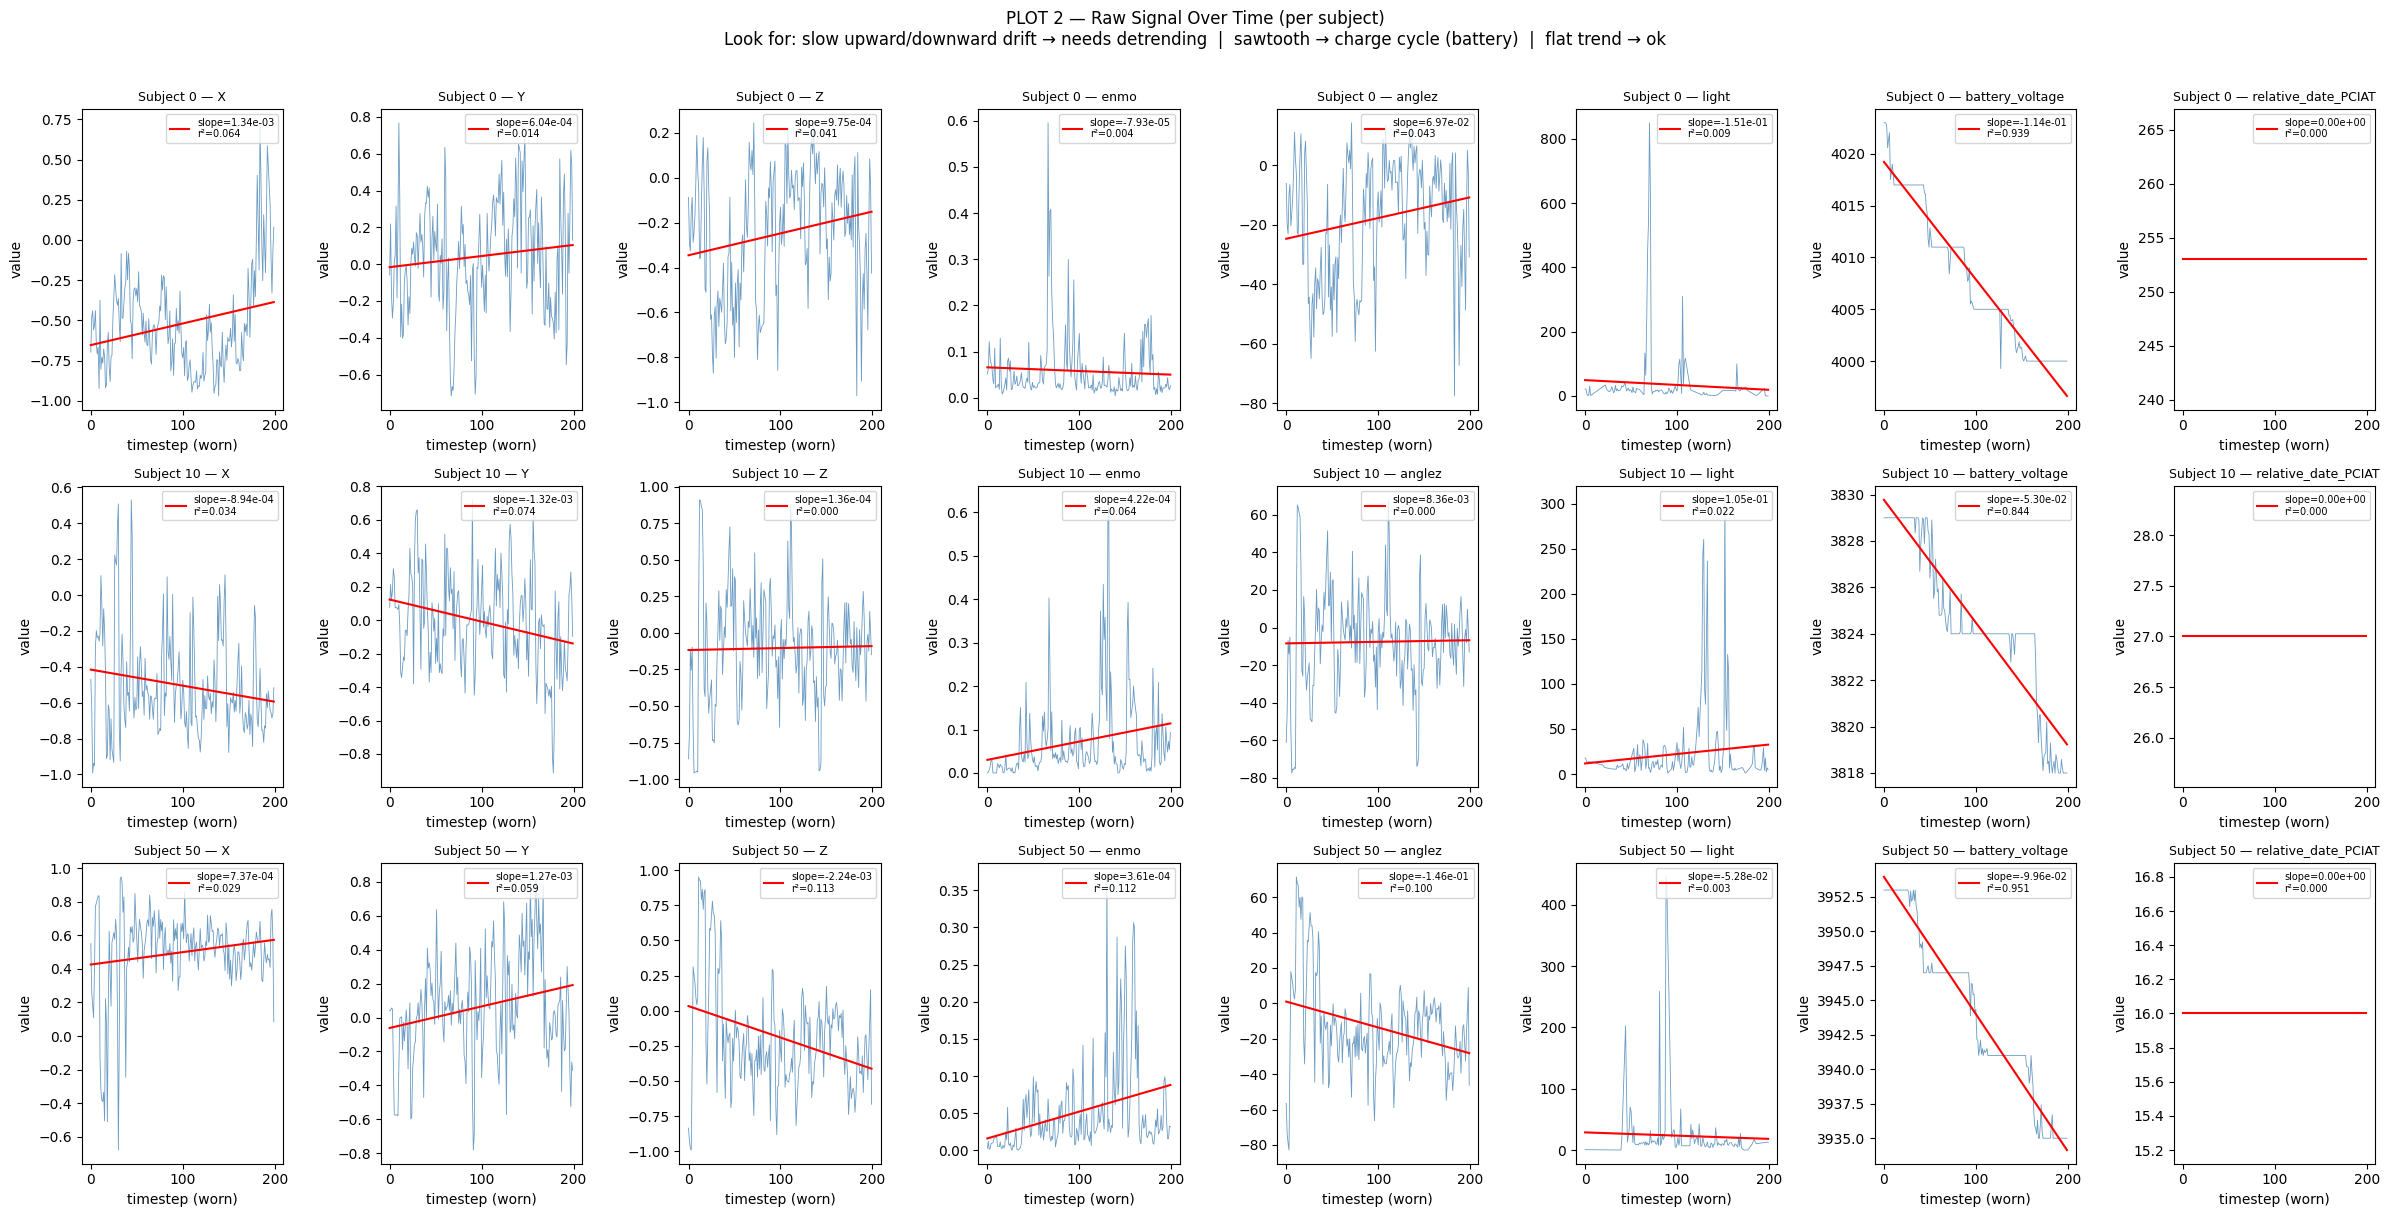

✅ Plot 2 saved: diag_2_timeseries.png


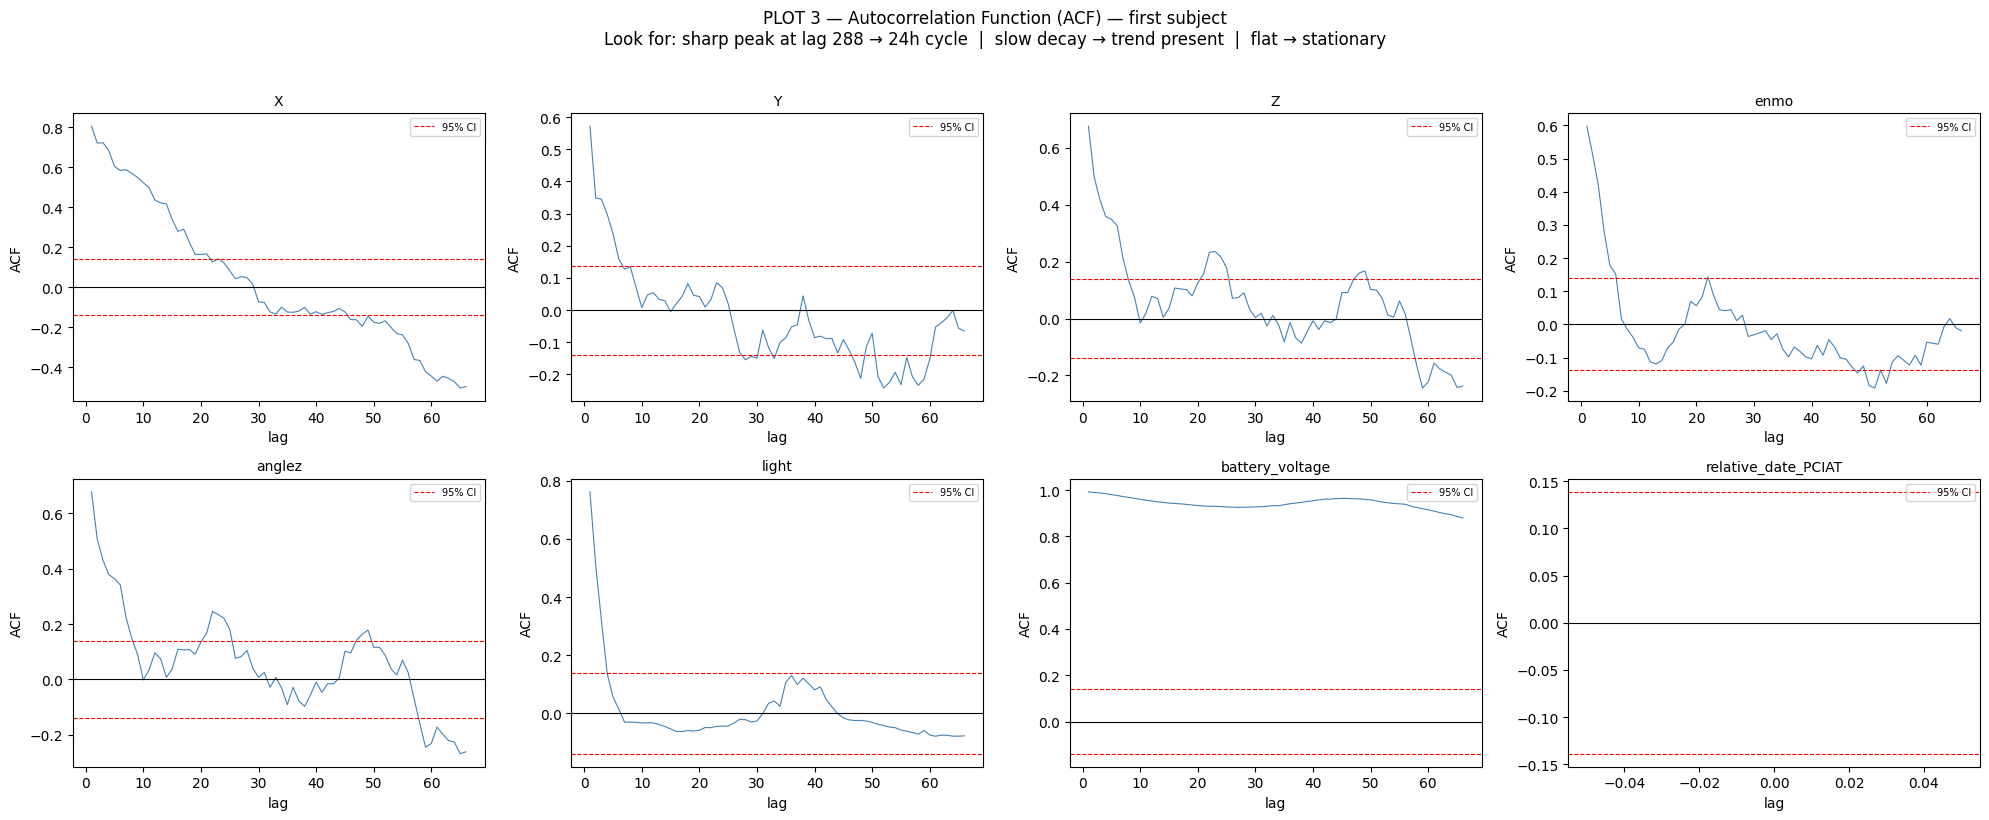

✅ Plot 3 saved: diag_3_acf.png


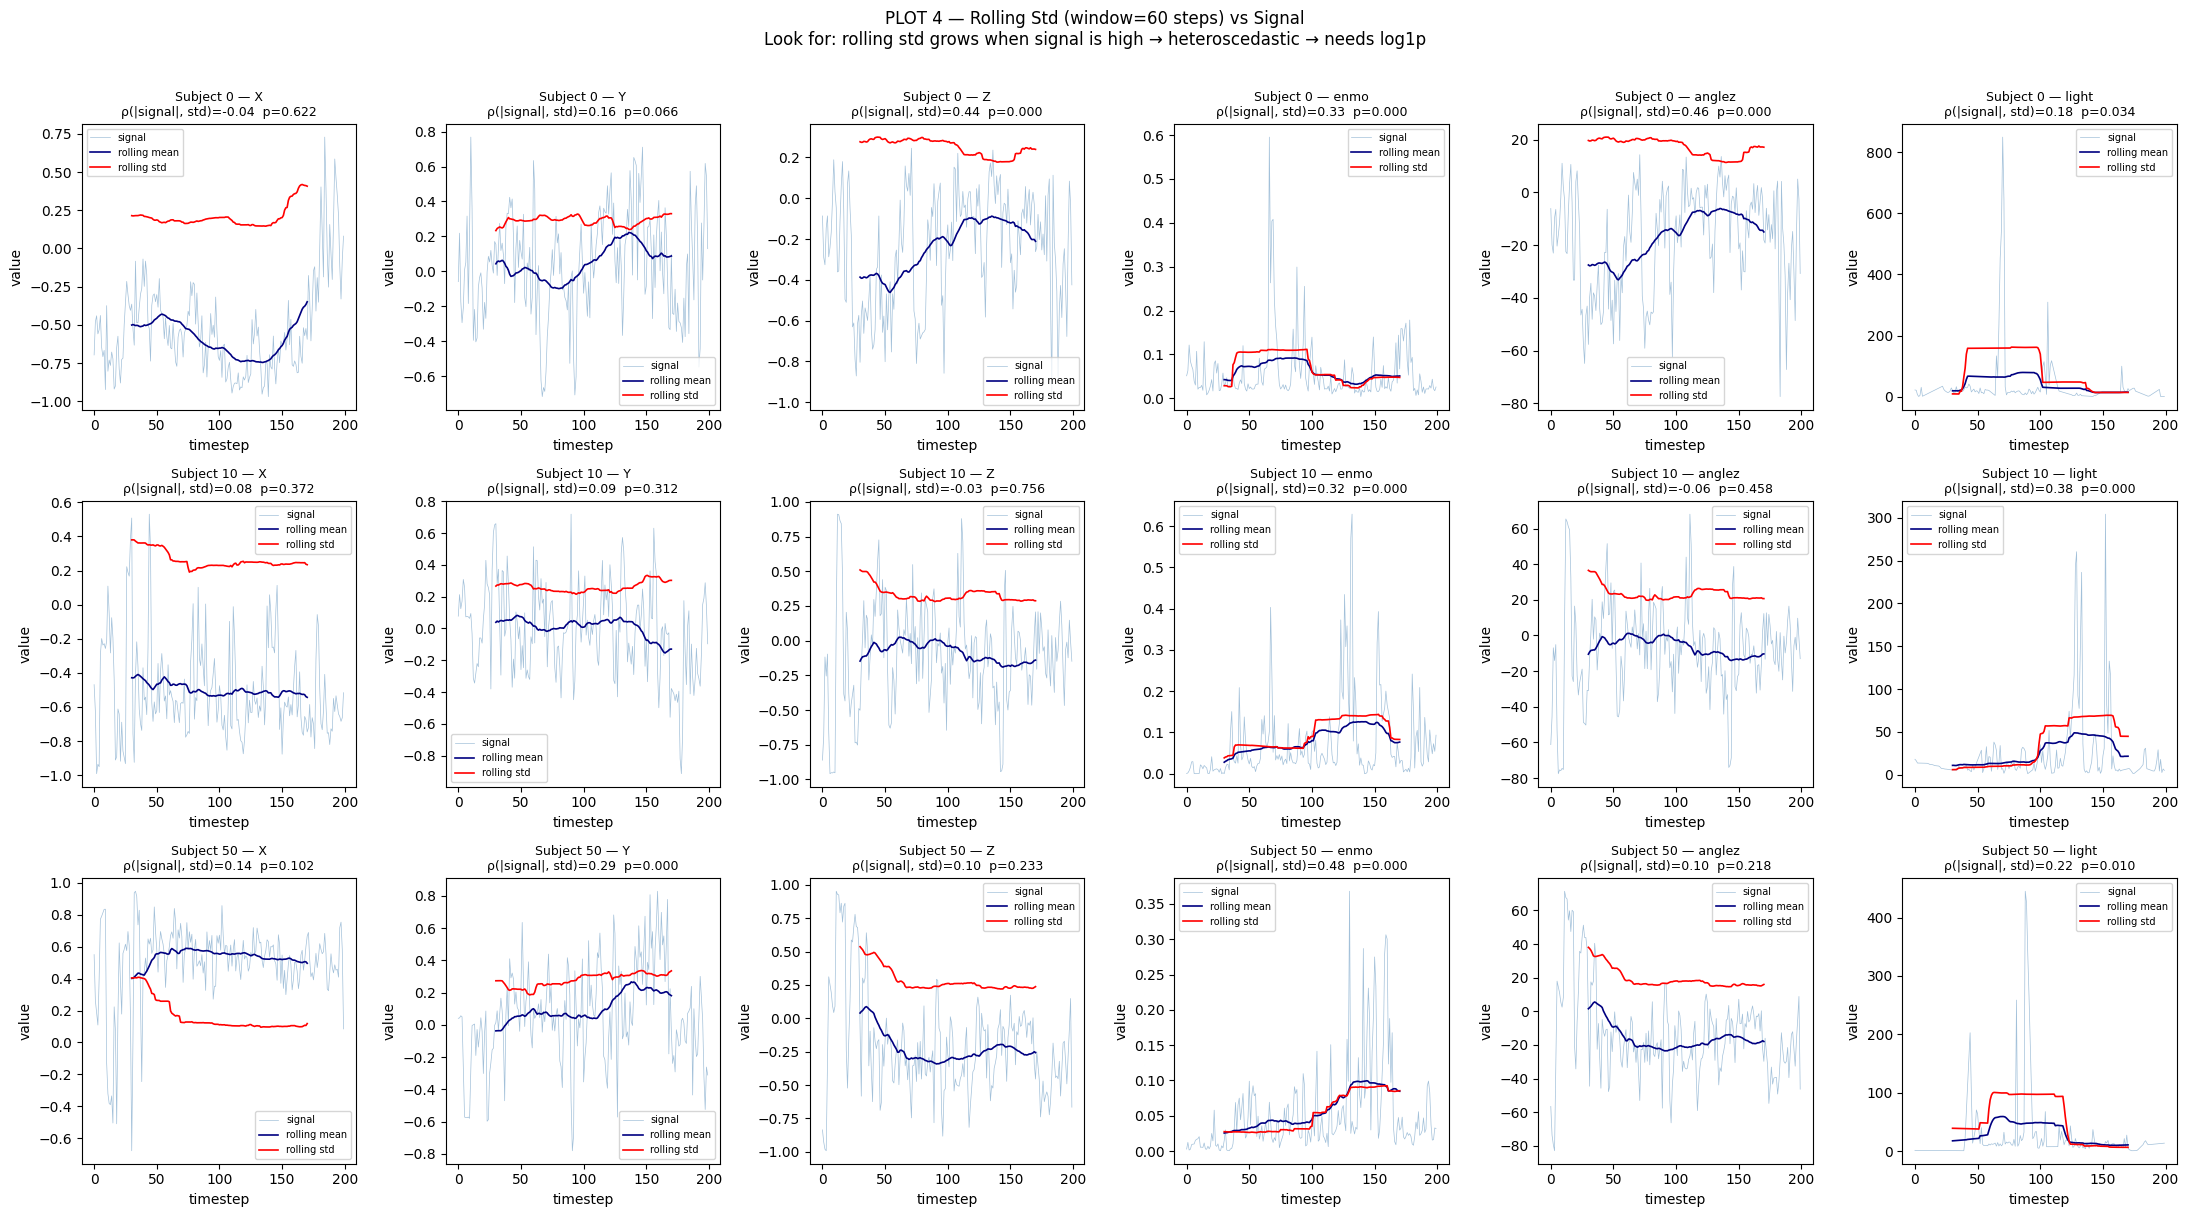

✅ Plot 4 saved: diag_4_heteroscedasticity.png

DIAGNOSTIC SUMMARY — what to look for in each plot
            Channel Plot 1: skewed? Plot 2: trend? Plot 3: periodic? Plot 4: heterosc.?   Expected transform
                  X           check          check              weak              check         RobustScaler
                  Y           check          check              weak              check         RobustScaler
                  Z           check          check              weak              check         RobustScaler
               enmo        ⚠ likely          check             ⚠ 24h           ⚠ likely log1p → RobustScaler
             anglez           check          check             ⚠ 24h              check         RobustScaler
              light        ⚠ likely          check             ⚠ 24h           ⚠ likely log1p → RobustScaler
    battery_voltage           check     ⚠ sawtooth    ⚠ charge cycle                 no         MinMaxScaler
relative_date_PCIAT           

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal, stats

# ── CONFIG ────────────────────────────────────────────────────────────────────

SENSOR_COLS  = ['X', 'Y', 'Z', 'enmo', 'anglez', 'light']
EXTRA_COLS   = ['battery_voltage', 'relative_date_PCIAT']
ALL_COLS     = SENSOR_COLS + EXTRA_COLS
NON_WEAR_THR = 0.5

# Pick a few representative subjects: one short, one long, one with gaps
SUBJECT_IDXS = [0, 10, 50]   # change these to any indices you want to inspect

# ── HELPERS ───────────────────────────────────────────────────────────────────

def get_worn(df):
    """Return only worn-time rows."""
    return df[df['non-wear_flag'] < NON_WEAR_THR]

def collect_global(col, log=False):
    """Pool worn values for a column across all subjects."""
    vals = []
    for df in CMI_timeseries_dataset:
        v = get_worn(df)[col].values
        if log:
            v = np.log1p(np.clip(v, 0, None))
        vals.extend(v)
    return np.array(vals)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — DISTRIBUTIONS (histogram + skewness)
# Answers: do I need log1p? do I need MinMax vs RobustScaler?
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("PLOT 1 — Global Distributions (worn rows only)\n"
             "Look for: right skew → needs log1p  |  symmetric → z-score ok  |  bounded → MinMax ok",
             fontsize=12, y=1.02)

log_cols = {'enmo', 'light'}

for ax, col in zip(axes.flatten(), ALL_COLS):
    raw  = collect_global(col)
    skew = stats.skew(raw)

    ax.hist(raw, bins=80, color='steelblue', alpha=0.7, density=True)
    ax.set_title(f"{col}\nskewness = {skew:.2f}", fontsize=10)
    ax.set_xlabel("value")
    ax.set_ylabel("density")

    if col in log_cols:
        ax2 = ax.twinx()
        log_vals = np.log1p(np.clip(raw, 0, None))
        ax2.hist(log_vals, bins=80, color='darkorange', alpha=0.4, density=True)
        ax2.set_ylabel("log1p density", color='darkorange')
        ax2.tick_params(axis='y', labelcolor='darkorange')
        ax.set_title(f"{col}\nskewness raw={skew:.2f}  "
                     f"log={stats.skew(log_vals):.2f}\n(blue=raw, orange=log1p)", fontsize=9)

plt.tight_layout()
plt.savefig("diag_1_distributions.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot 1 saved: diag_1_distributions.png")

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2 — TIME SERIES over full recording (trend detection)
# Answers: does the signal drift over time? → needs detrending
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(len(SUBJECT_IDXS), len(ALL_COLS),
                         figsize=(24, 4 * len(SUBJECT_IDXS)))
fig.suptitle("PLOT 2 — Raw Signal Over Time (per subject)\n"
             "Look for: slow upward/downward drift → needs detrending  |  "
             "sawtooth → charge cycle (battery)  |  flat trend → ok",
             fontsize=12, y=1.01)

for row, idx in enumerate(SUBJECT_IDXS):
    df   = data_interp[idx]
    worn = get_worn(df)
    t    = np.arange(len(worn))

    for col_i, col in enumerate(ALL_COLS):
        ax = axes[row, col_i] if len(SUBJECT_IDXS) > 1 else axes[col_i]
        y  = worn[col].values

        ax.plot(t, y, lw=0.6, color='steelblue', alpha=0.8)

        # Overlay linear trend
        if len(t) > 2:
            slope, intercept, r, *_ = stats.linregress(t, y)
            ax.plot(t, intercept + slope * t, color='red', lw=1.5,
                    label=f"slope={slope:.2e}\nr²={r**2:.3f}")
            ax.legend(fontsize=7, loc='upper right')

        ax.set_title(f"Subject {idx} — {col}", fontsize=9)
        ax.set_xlabel("timestep (worn)")
        ax.set_ylabel("value")

plt.tight_layout()
plt.savefig("diag_2_timeseries.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot 2 saved: diag_2_timeseries.png")

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3 — AUTOCORRELATION FUNCTION (periodicity detection)
# Answers: are there regular cycles? → what period? → needs STL?
# ─────────────────────────────────────────────────────────────────────────────

MAX_LAGS = 500   # adjust: at 5-min bins, 288 = 24h, 2016 = 7 days

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("PLOT 3 — Autocorrelation Function (ACF) — first subject\n"
             "Look for: sharp peak at lag 288 → 24h cycle  |  "
             "slow decay → trend present  |  flat → stationary",
             fontsize=12, y=1.02)

df_ref  = data_interp[SUBJECT_IDXS[0]]
worn_ref = get_worn(df_ref)

for ax, col in zip(axes.flatten(), ALL_COLS):
    y = worn_ref[col].values
    y = (y - np.mean(y)) / (np.std(y) + 1e-8)   # normalise before ACF

    n    = len(y)
    lags = min(MAX_LAGS, n // 3)
    acf_vals = [np.corrcoef(y[:n-k], y[k:])[0, 1] for k in range(1, lags + 1)]

    ax.plot(range(1, lags + 1), acf_vals, lw=0.8, color='steelblue')
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline( 1.96 / np.sqrt(n), color='red', lw=0.8, ls='--', label='95% CI')
    ax.axhline(-1.96 / np.sqrt(n), color='red', lw=0.8, ls='--')

    # Mark 24h and 7-day lags if in range
    for lag, label in [(288, '24h'), (2016, '7d')]:
        if lag < lags:
            ax.axvline(lag, color='orange', lw=1.2, ls=':', label=label)

    ax.set_title(col, fontsize=10)
    ax.set_xlabel("lag")
    ax.set_ylabel("ACF")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("diag_3_acf.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot 3 saved: diag_3_acf.png")

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 4 — ROLLING STANDARD DEVIATION (heteroscedasticity detection)
# Answers: does variance change over time or with activity level?
# → needs log1p or variance-stabilising transform
# ─────────────────────────────────────────────────────────────────────────────

WINDOW = 60   # rolling window in timesteps (e.g. 60 × 5min = 5h)

fig, axes = plt.subplots(len(SUBJECT_IDXS), len(SENSOR_COLS),
                         figsize=(22, 4 * len(SUBJECT_IDXS)))
fig.suptitle(f"PLOT 4 — Rolling Std (window={WINDOW} steps) vs Signal\n"
             "Look for: rolling std grows when signal is high → heteroscedastic → needs log1p",
             fontsize=12, y=1.01)

for row, idx in enumerate(SUBJECT_IDXS):
    df   = data_interp[idx]
    worn = get_worn(df)

    for col_i, col in enumerate(SENSOR_COLS):
        ax = axes[row, col_i] if len(SUBJECT_IDXS) > 1 else axes[col_i]
        s  = pd.Series(worn[col].values)

        rolling_mean = s.rolling(WINDOW, center=True).mean()
        rolling_std  = s.rolling(WINDOW, center=True).std()

        ax.plot(s.values,            lw=0.5, color='steelblue', alpha=0.5, label='signal')
        ax.plot(rolling_mean.values, lw=1.2, color='navy',      label='rolling mean')
        ax.plot(rolling_std.values,  lw=1.2, color='red',       label='rolling std')

        # Pearson r between |signal| and rolling std → quantifies heteroscedasticity
        valid = ~rolling_std.isna()
        if valid.sum() > 10:
            r, p = stats.pearsonr(np.abs(s[valid]), rolling_std[valid])
            ax.set_title(f"Subject {idx} — {col}\nρ(|signal|, std)={r:.2f}  p={p:.3f}",
                         fontsize=9)
        else:
            ax.set_title(f"Subject {idx} — {col}", fontsize=9)

        ax.legend(fontsize=7)
        ax.set_xlabel("timestep")
        ax.set_ylabel("value")

plt.tight_layout()
plt.savefig("diag_4_heteroscedasticity.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot 4 saved: diag_4_heteroscedasticity.png")

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 5 — SUMMARY DECISION TABLE
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 70)
print("DIAGNOSTIC SUMMARY — what to look for in each plot")
print("=" * 70)

summary = pd.DataFrame({
    'Channel': ALL_COLS,
    'Plot 1: skewed?':    ['check', 'check', 'check', '⚠ likely', 'check', '⚠ likely', 'check', 'check'],
    'Plot 2: trend?':     ['check', 'check', 'check', 'check', 'check', 'check', '⚠ sawtooth', '⚠ long-term'],
    'Plot 3: periodic?':  ['weak', 'weak', 'weak', '⚠ 24h', '⚠ 24h', '⚠ 24h', '⚠ charge cycle', 'no'],
    'Plot 4: heterosc.?': ['check', 'check', 'check', '⚠ likely', 'check', '⚠ likely', 'no', 'no'],
    'Expected transform': [
        'RobustScaler',
        'RobustScaler',
        'RobustScaler',
        'log1p → RobustScaler',
        'RobustScaler',
        'log1p → RobustScaler',
        'MinMaxScaler',
        'per-subject z-score'
    ]
})

print(summary.to_string(index=False))
print("\n⚠ = expected issue based on domain knowledge — confirm visually in the plots above")